2025-07-05 21:58:25.644408: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-05 21:58:25.674774: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-05 21:58:25.674795: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-05 21:58:25.675957: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-05 21:58:25.681988: I tensorflow/core/platform/cpu_feature_guar

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
data ['LA_RSPV_CAF_150115', 'Simulation_01_200428_001_001', 'Simulation_01_200316_001_  5', 'Simulation_01_191001_001_002', 'Simulation_01_200428_001_005', 'Simulation_01_190717_001_001', 'Simulation_01_200212_001_  7', 'Simulation_01_191001_001_007', 'LA_RSPV_150113', 'Simulation_01_210119_001_001', 'Simulation_01_210205_001_003', 'LA_PLAW_140612', 'Simulation_01_190717_001_004', 'Simulation_01_201223_001_002', 'Simulation_01_200212_001_  1', 'LA_LSPV_150203', 'Simulation_01_190619_001_003', 'Simulation_01_200428_001_003', 'Simulation_01_190619_001_004', 'Simulation_01_190717_001_003', 'Simulation_01_190502_001_006', 'LA_LSPV_150113', 'Simulation_01_190502_001_004', 'RA_RAFW_140807', 'Simulation_01_190717_001_002', 'Simulation_01_200316_001_  3', 'Simulation_01_200316_001_  4', 'RA_RAA_141230', 'Sinusal_150629', 'RA_RAA_141216', 'Simulation_01_200428_001

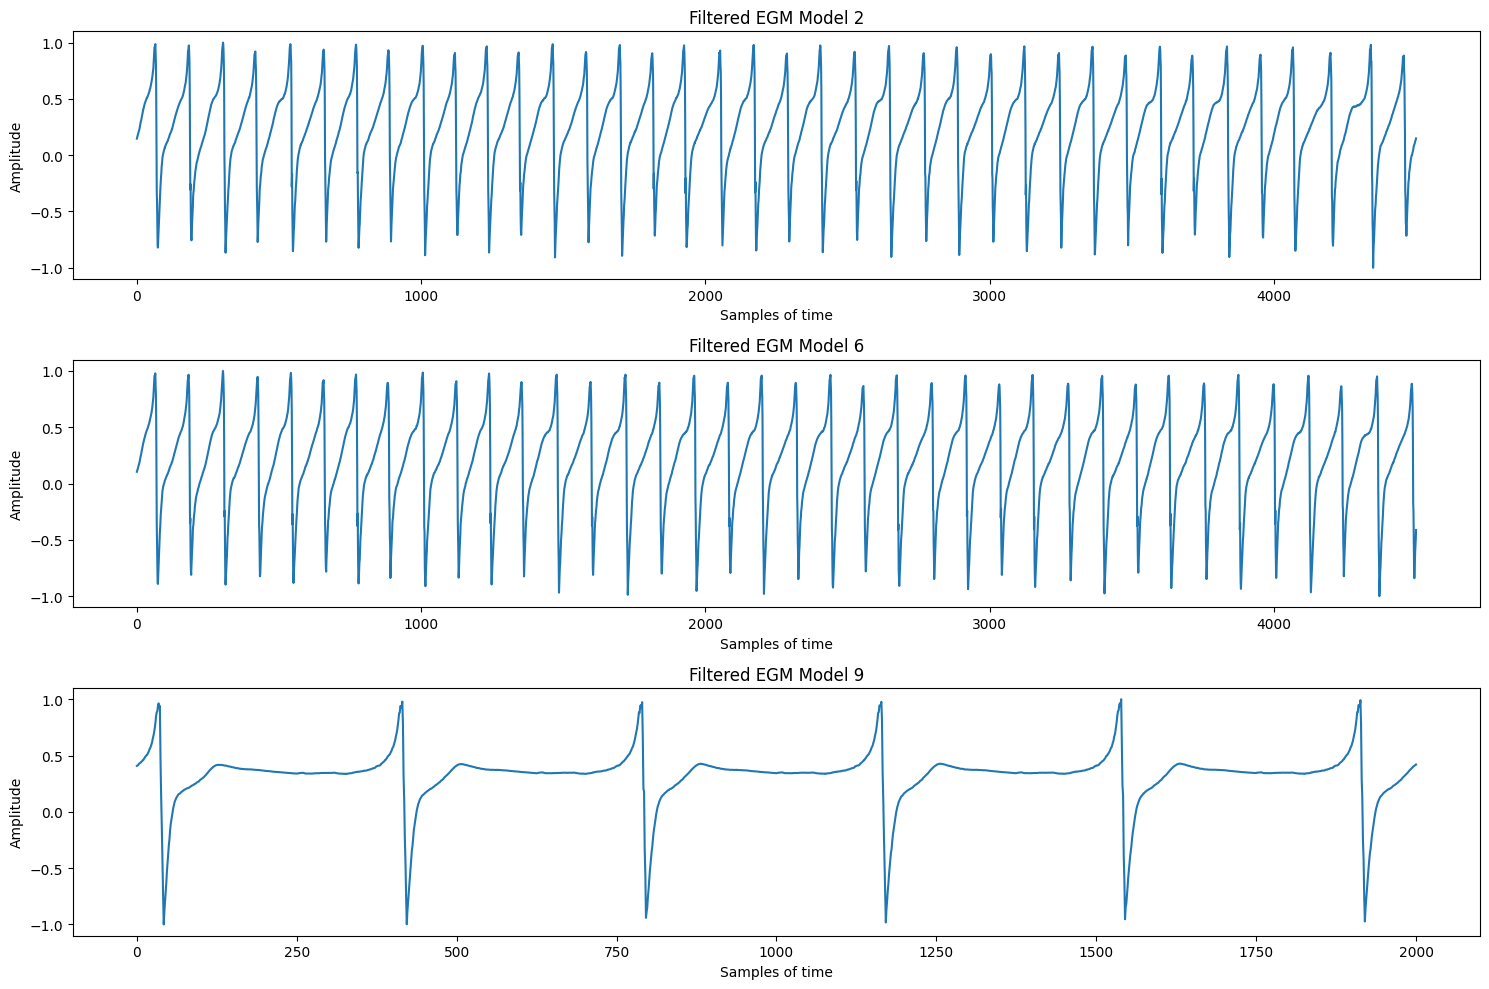

10
Transfer matrices LOADED - var: **transfer_matrices** 
BSPS Models LOADED - var: **bsps_all_models** 
BSPS 64 Models LOADED - var: **bsps_64_all_models** 
550
(3610, 2499)
(3610, 2499)
(64, 2499)
(3970, 2499)
(64, 2499)
(64, 2001)
550
BSPS 64 Models LOADED - var: **bsps_64_all_models** 


In [1]:
import os
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/home/alumnos/mburgosc/cuda-fake"

import tensorflow as tf

import tensorflow as tf 
import numpy as np
gpus = tf.config.list_physical_devices("GPU")

print(gpus)

import import_data

egms_all_models = import_data.egms_all_models
egms_values = import_data.egms_values
egms_filtered_norm = import_data.egms_filtered_norm
bsps_all_models = import_data.bsps_all_models
bsps_64_all_models = import_data.bsps_64_all_models
transfer_matrices = import_data.transfer_matrices
models_names = import_data.models_names
bsps_64_all_models_names = import_data.bsps_64_all_models_names


In [2]:

print(len(bsps_64_all_models_names))
# models_name_full = []
# for name in models_names:
#     models_name_full.extend([name] * 10)

models_name_full = bsps_64_all_models_names
# Verifica que coinciden
print(len(models_name_full))  # Debería dar 240
filtered_models = []
filtered_models_names = []

for model, name_model in zip(bsps_64_all_models, models_name_full):
    new_model = []
    new_model2 = []

    for node in model:
        original_length = len(node)

        if original_length < 2000:
            continue

        if 2000 <= original_length <= 2501:
            node = node[:2000]
            new_model.append(node)
        elif 4000 <= original_length <= 4501:
            node = node[:4000]
            new_model.append(node[0:2000])
            new_model2.append(node[2000:4000])
        else:
            continue


    if len(new_model) > 0:
        filtered_models.append(new_model)
        filtered_models_names.append(name_model)  # Añadimos el nombre del modelo
    if len(new_model2) > 0:
        filtered_models.append(new_model2)
        filtered_models_names.append(name_model)
        
bsps_64_filtered_models = filtered_models

print(len(bsps_64_filtered_models))
print(len(filtered_models_names))
print(filtered_models_names)
print(bsps_64_filtered_models[0])

print(filtered_models_names[140])

550
550
830
830
['LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_0

In [3]:
from collections import OrderedDict
unique_models = list(OrderedDict.fromkeys(filtered_models_names))
print(len(unique_models))
print(unique_models)

model_to_indices = {m: [] for m in unique_models}  # DICCIONARIO CON NOMBRES DE MODELOS Y SUS INDICES EN filtered_models_names
for i, name in enumerate(filtered_models_names):
    if name in unique_models:
        model_to_indices[name].append(i)
print(f"Índices de modelos: {model_to_indices}")

54
['LA_RSPV_CAF_150115', 'Simulation_01_200316_001_  5', 'Simulation_01_191001_001_002', 'Simulation_01_200428_001_005', 'Simulation_01_190717_001_001', 'Simulation_01_200212_001_  7', 'Simulation_01_191001_001_007', 'LA_RSPV_150113', 'Simulation_01_190717_001_004', 'Simulation_01_200212_001_  1', 'LA_LSPV_150203', 'Simulation_01_190619_001_003', 'Simulation_01_200428_001_003', 'Simulation_01_190619_001_004', 'Simulation_01_190717_001_003', 'Simulation_01_190502_001_006', 'LA_LSPV_150113', 'Simulation_01_190502_001_004', 'RA_RAFW_140807', 'Simulation_01_190717_001_002', 'Simulation_01_200316_001_  3', 'Simulation_01_200316_001_  4', 'RA_RAA_141230', 'Sinusal_150629', 'RA_RAA_141216', 'Simulation_01_190619_001_001', 'Simulation_01_200212_001_  9', 'Simulation_01_200316_001_  1', 'Simulation_01_200316_001_  8', 'Simulation_01_200428_001_004', 'Simulation_01_200212_001_  8', 'Simulation_01_200212_001_ 10', 'Simulation_01_191001_001_001', 'Simulation_01_200428_001_007', 'Simulation_01_200

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split


# Leer el CSV
csv_df = pd.read_csv('annotations.csv', header=None)

# Separar por ';'
csv_split = csv_df[0].str.split(';', expand=True)
csv_names = csv_split[0].str.strip().tolist()  # Eliminar espacios
csv_labels = csv_split[1].astype(int).tolist()

# Lista de modelos únicos que quieres filtrar (asegúrate de que está definida)
# unique_models = [...]

# Crear un diccionario con todos los nombres y etiquetas
name_to_label = dict(zip(csv_names, csv_labels))

# Filtrar sólo los que están en unique_models
filtered_unique_models = [m for m in unique_models if name_to_label.get(m) != 1]
print(len(filtered_unique_models))

filtered_labels = [name_to_label[m] for m in filtered_unique_models]

train_models, test_models, train_labels, test_labels = train_test_split(
    filtered_unique_models,
    filtered_labels,
    test_size=0.3,
    stratify=filtered_labels,
    random_state=42
)

# Mostrar resultados
print(filtered_labels)
print(len(filtered_labels))

print("Total modelos únicos con etiqueta:", len(filtered_unique_models))


print("Modelos de entrenamiento:", len(train_models))
print("Modelos de prueba:", len(test_models))
print("Etiquetas de entrenamiento:", len(train_labels))
print("Etiquetas de prueba:", len(test_labels))

# Opcional: Ver distribución
from collections import Counter
print("Distribución train:", Counter(train_labels))
print("Distribución test:", Counter(test_labels))

52
[3, 4, 2, 4, 2, 4, 2, 3, 2, 4, 3, 2, 4, 2, 2, 2, 3, 2, 3, 2, 4, 2, 3, 4, 2, 4, 4, 2, 2, 2, 2, 2, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 3, 2, 2, 2, 3, 4]
52
Total modelos únicos con etiqueta: 52
Modelos de entrenamiento: 36
Modelos de prueba: 16
Etiquetas de entrenamiento: 36
Etiquetas de prueba: 16
Distribución train: Counter({2: 21, 4: 9, 3: 6})
Distribución test: Counter({2: 10, 4: 4, 3: 2})


In [5]:
print(len(train_models))
print(len(test_models))

36
16


type 3 LA_RSPV_CAF_150115
LA_RSPV_CAF_150115
3
type 4 Simulation_01_200316_001_  5
Simulation_01_200316_001_  5
4
type 2 Simulation_01_191001_001_002
Simulation_01_191001_001_002
2


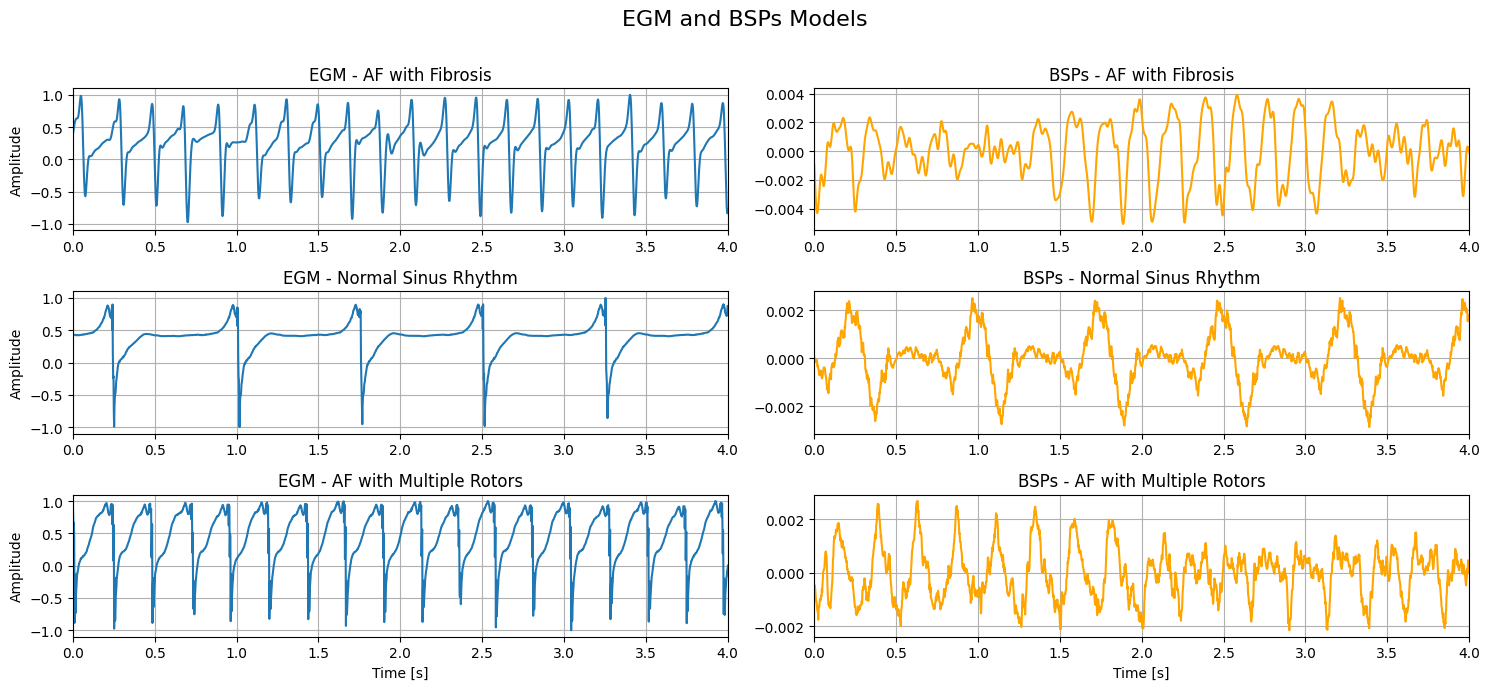

In [6]:
import matplotlib.pyplot as plt
import numpy as np


filtered_models_egm = import_data.filtered_model_names
fs = 500  # frecuencia de muestreo
t_limit = 2000 / fs  # tiempo en segundos para limitar el eje x

# Crear figura y subplots
fig, axs = plt.subplots(3, 2, figsize=(15, 7))
plt.suptitle("EGM and BSPs Models", fontsize=16)

# Lista de datos a graficar: [(índice en listas, título general, etiqueta)]
signals_info = [
    (0, "AF with Fibrosis", "type 3"),
    (1, "Normal Sinus Rhythm", "type 4"),
    (2, "AF with Multiple Rotors", "type 2")
]

# Índices de BSPs
bsps_indices = [0, 11, 20]  # puedes ajustar si es necesario

for i, (idx_model, title, label) in enumerate(signals_info):
    print(label, bsps_64_all_models_names[bsps_indices[i]])
    print(filtered_models_egm[idx_model])
    print(filtered_labels[idx_model])

    # Tiempo
    N = len(egms_filtered_norm[idx_model][0])
    t = np.arange(N) / fs

    # EGM
    axs[i, 0].plot(t, egms_filtered_norm[idx_model][0])
    axs[i, 0].set_xlim(0, t_limit)
    axs[i, 0].set_title(f"EGM - {title}")
    if i == 2:
        axs[i, 0].set_xlabel("Time [s]")
    axs[i, 0].set_ylabel("Amplitude")
    axs[i, 0].grid(True)

    # BSP
    bsp_signal = np.array(bsps_64_all_models[bsps_indices[i]][0])
    bsp_signal_centered = bsp_signal - np.mean(bsp_signal)
    axs[i, 1].plot(t, bsp_signal_centered, color="orange")
    axs[i, 1].set_xlim(0, t_limit)
    axs[i, 1].set_title(f"BSPs - {title}")
    if i == 2:
        axs[i, 1].set_xlabel("Time [s]")
    # No poner ylabel aquí
    axs[i, 1].grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.97])  # deja espacio para el suptitle
plt.show()


Simulation_01_190717_001_001
Simulation_01_190717_001_001
2


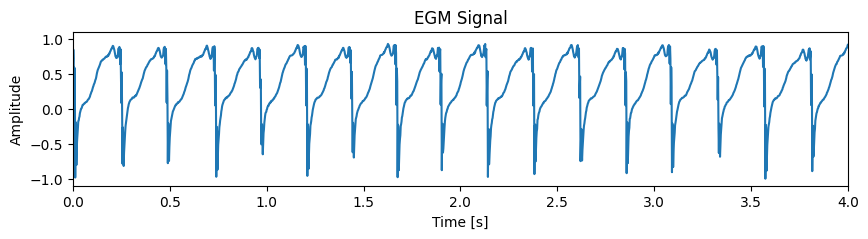

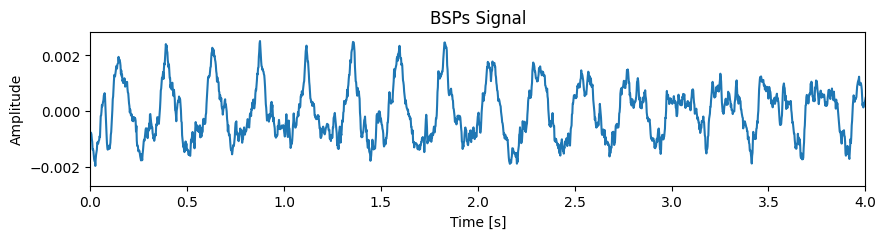

In [7]:
print(bsps_64_all_models_names[40])
print(filtered_models_egm[4])
print(filtered_labels[40])

N = len(egms_filtered_norm[4][0])
t = np.arange(N) / fs

# EGM
plt.figure(figsize=(10, 2))
plt.plot(t, egms_filtered_norm[4][0])
plt.xlim(0, t_limit)
plt.title(f"EGM Signal")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.show()


plt.figure(figsize=(10, 2))
bsp_signal = np.array(bsps_64_all_models[40][0])
bsp_signal_centered = bsp_signal - np.mean(bsp_signal)
plt.plot(t, bsp_signal_centered)
plt.xlim(0, t_limit)
plt.title(f"BSPs Signal")
plt.xlabel("Time [s]")
plt.ylabel("Amplitude")
plt.show()

In [8]:
used_train_models = []
used_test_models = []

X_train = []
y_train = []

for model_name, label in zip(train_models, train_labels):
    indices = model_to_indices.get(model_name, [])
    for idx in indices:
        X_train.append(filtered_models[idx])
        y_train.append(label)
        used_train_models.append(model_name)

X_test = []
y_test = []

for model_name, label in zip(test_models, test_labels):
    indices = model_to_indices.get(model_name, [])
    for idx in indices:
        X_test.append(filtered_models[idx])
        y_test.append(label)
        used_test_models.append(model_name)
        
# Verificación rápida
print(f"Total X_train: {len(X_train)}, y_train: {len(y_train)}")
print(f"Total X_test: {len(X_test)}, y_test: {len(y_test)}")

print(Counter(y_train))
print(Counter(y_test))

X_train = np.array(X_train)
X_test = np.array(X_test)



Total X_train: 560, y_train: 560
Total X_test: 250, y_test: 250
Counter({2: 410, 4: 90, 3: 60})
Counter({2: 190, 4: 40, 3: 20})


In [9]:
# FUNCTIONS --> ADD_NOISE + FILTERING
from scipy.signal import butter, filtfilt
from add_white_noise import addwhitenoise

# Parámetros
fs = 500  # Frecuencia de muestreo
cutoff = 40  # Frecuencia de corte del filtro LPF

# Función para crear y aplicar un filtro paso bajo
def lowpass_filter(signal, cutoff, fs, order=4):
    nyq = 0.5 * fs  # Frecuencia de Nyquist
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    filtered_signal = filtfilt(b, a, signal)
    return filtered_signal

# Selecciona el modelo

def extract_filtered_data(X, fs, SNR, cutoff):
    filtered_data = []
    for model in X:
        model = np.array(model)
        model = model - np.mean(model, axis=1, keepdims=True)  # Centrado
        model_noisy_T, _ = addwhitenoise(model, SNR=SNR, fs=fs, plot_figure='False')
        model_noisy = model_noisy_T
        senal_filtrada = lowpass_filter(model_noisy, cutoff=cutoff, fs=fs)
        filtered_data.append(senal_filtrada)
    return np.array(filtered_data)

X_train_filt_10dB = extract_filtered_data(X_train, fs=500, SNR=10, cutoff=40)
X_test_filt_10dB = extract_filtered_data(X_test, fs=500, SNR=10, cutoff=40)

print(f"Datos filtrados: {X_train_filt_10dB.shape}, {X_test_filt_10dB.shape}")

X_train_filt_20dB = extract_filtered_data(X_train, fs=500, SNR=20, cutoff=40)
X_test_filt_20dB = extract_filtered_data(X_test, fs=500, SNR=20, cutoff=40)

print(f"Datos filtrados: {X_train_filt_10dB.shape}, {X_test_filt_10dB.shape}")


Datos filtrados: (560, 64, 2000), (250, 64, 2000)
Datos filtrados: (560, 64, 2000), (250, 64, 2000)


Original data: 95% variance → 1 components
Original data: 99% variance → 3 components
Noise filtered data (SNR=10 dB): 95% variance → 5 components
Noise filtered data (SNR=10 dB): 99% variance → 17 components
Noise filtered data (SNR=20 dB): 95% variance → 5 components
Noise filtered data (SNR=20 dB): 99% variance → 8 components


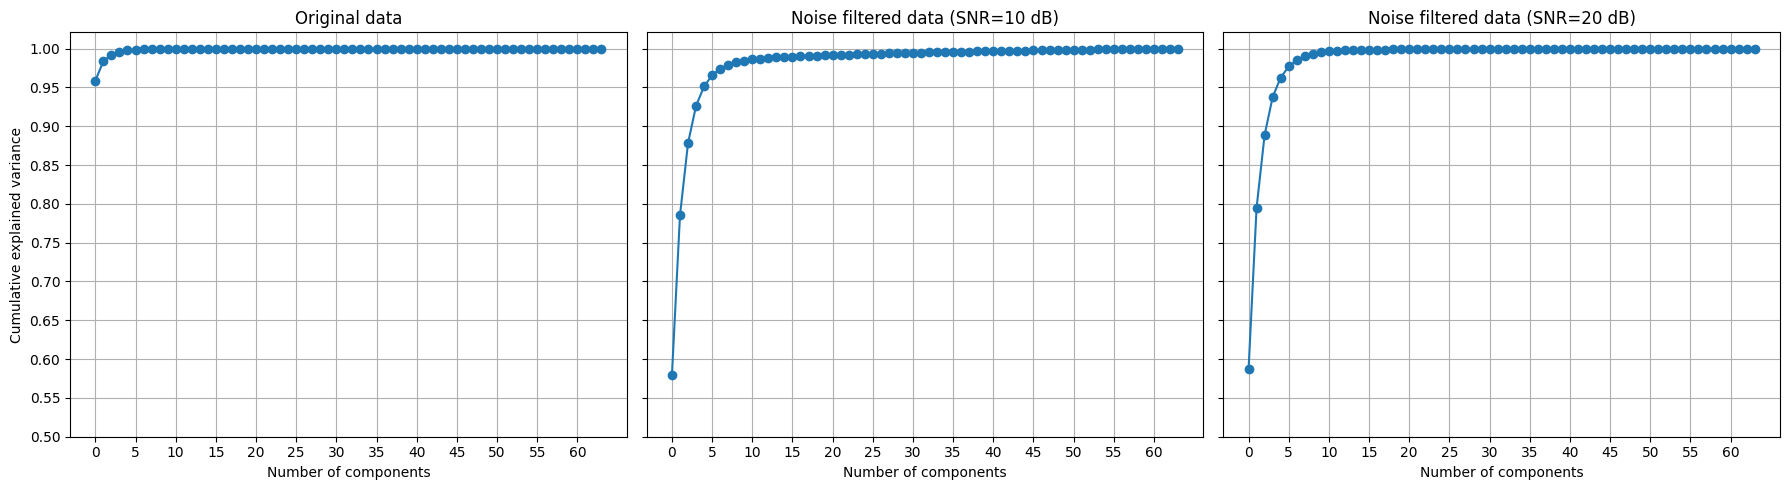

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Lista con tus datasets
datasets = {
    "Original data": X_train,
    "Noise filtered data (SNR=10 dB)": X_train_filt_10dB,
    "Noise filtered data (SNR=20 dB)": X_train_filt_20dB
}

# Configuración
np.random.seed(42)
thresholds = [0.95, 0.99]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)  # 1 fila, 3 columnas

# Recorremos cada conjunto de datos
for i, (label, data) in enumerate(datasets.items()):
    num_models = len(X_train)
    total_models = data.shape[0]

    # Selección aleatoria de modelos
    random_indices = np.random.choice(total_models, size=num_models, replace=False)
    all_cum_var = []

    # PCA por modelo
    for idx in random_indices:
        model = data[idx]  # shape: (64, 1000)
        pca = PCA()
        pca.fit(model)
        cum_var = np.cumsum(pca.explained_variance_ratio_)
        all_cum_var.append(cum_var)

    all_cum_var = np.array(all_cum_var)
    mean_cum_var = np.mean(all_cum_var, axis=0)

    # Gráfico
    axes[i].plot(mean_cum_var, marker='o')
    axes[i].set_title(label)
    axes[i].set_xlabel('Number of components')
    axes[i].set_yticks(np.arange(0.5, 1.01, 0.05))
    axes[i].set_xticks(np.arange(0.0, 64, 5))
    if i == 0:
        axes[i].set_ylabel('Cumulative explained variance')
    axes[i].grid(True)

    # Calcular componentes para umbrales
    for t in thresholds:
        n_components = np.argmax(mean_cum_var >= t) + 1
        print(f"{label}: {t*100:.0f}% variance → {n_components} components")

plt.tight_layout()
plt.show()


In [10]:
# PRINCIPAL COMPONENT ANALYSIS (PCA)

from sklearn.decomposition import PCA

def apply_pca(X, n_components):
    # APLICAR PCA A CADA MODELO
    n_components = n_components
    X_pca = []
    for model in X:
        model_T = model.T  # Transponer para que las muestras sean filas
        pca = PCA(n_components=n_components, random_state=42)
        model_pca = pca.fit_transform(model_T)  # (1000, 2)

        # Si quieres devolverlo como (64, 2) puedes transponer de nuevo
        model_pca = model_pca.T  # (2, 1000)
        X_pca.append(model_pca)

    return np.array(X_pca)

#original_data
X_train_pca = apply_pca(X_train, n_components=4)
X_test_pca = apply_pca(X_test, n_components=4)

#filtered_data_10dB
X_train_filt_10dB_pca = apply_pca(X_train_filt_10dB, n_components=4)
X_test_filt_10dB_pca = apply_pca(X_test_filt_10dB, n_components=4)

#filtered_data_20dB
X_train_filt_20dB_pca = apply_pca(X_train_filt_20dB, n_components=4)
X_test_filt_20dB_pca = apply_pca(X_test_filt_20dB, n_components=4)


print(f"PCA aplicado por modelo. Ejemplo dimensiones: {X_train_pca[0].shape} ")
print(f"PCA aplicado por modelo. Ejemplo dimensiones: {X_train_filt_10dB_pca[0].shape} ")
print(f"PCA aplicado por modelo. Ejemplo dimensiones: {X_train_filt_20dB_pca[0].shape} ")
print(f"No PCA applied. Ejemplo dimensiones: {X_train[0].shape} ")

PCA aplicado por modelo. Ejemplo dimensiones: (4, 2000) 
PCA aplicado por modelo. Ejemplo dimensiones: (4, 2000) 
PCA aplicado por modelo. Ejemplo dimensiones: (4, 2000) 
No PCA applied. Ejemplo dimensiones: (64, 2000) 


In [51]:
# WAVELET SCATTERING TRANSFORM

from kymatio import Scattering1D

def apply_wavelet_scattering(X, J=4, Q=(16, 16)):
    # APLICAR SCATTERING A CADA MODELO
    J = 4
    Q = (16,16)

    ws_coeffs = []  

    for model in X:
        model_coeffs = []  
        
        for j in range(len(model)):
            signal = np.array(model[j])  
            len_signal = len(signal)
            
            scattering = Scattering1D(J=J, shape=(len_signal,), Q=Q)
            Sx = scattering(signal)  
            model_coeffs.append(Sx)  
        ws_coeffs.append(np.stack(model_coeffs))
    return np.array(ws_coeffs)

#original_data
X_train_ws = apply_wavelet_scattering(X_train_pca)
X_test_ws = apply_wavelet_scattering(X_test_pca)

#filtered_data_10dB
X_train_filt_10dB_ws = apply_wavelet_scattering(X_train_filt_10dB_pca)
X_test_filt_10dB_ws = apply_wavelet_scattering(X_test_filt_10dB_pca)

#filtered_data_20dB
X_train_filt_20dB_ws = apply_wavelet_scattering(X_train_filt_20dB_pca)
X_test_filt_20dB_ws = apply_wavelet_scattering(X_test_filt_20dB_pca)

#original_data NO PCA
X_train_ws_no_pca = apply_wavelet_scattering(X_train)
X_test_ws_no_pca = apply_wavelet_scattering(X_test)

print(f"Scattering aplicado por modelo. Ejemplo dimensiones: {X_train_ws[0].shape} ")
print(f"Scattering aplicado por modelo. Ejemplo dimensiones: {X_train_filt_10dB_ws[0].shape} ")
print(f"Scattering aplicado por modelo. Ejemplo dimensiones: {X_train_filt_20dB_ws[0].shape} ")
print(f"Scattering aplicado por modelo. Ejemplo dimensiones: {X_train_ws_no_pca[0].shape} ")



Scattering aplicado por modelo. Ejemplo dimensiones: (4, 326, 125) 
Scattering aplicado por modelo. Ejemplo dimensiones: (4, 326, 125) 
Scattering aplicado por modelo. Ejemplo dimensiones: (4, 326, 125) 
Scattering aplicado por modelo. Ejemplo dimensiones: (64, 326, 125) 


2000
[0.000e+00 2.000e-03 4.000e-03 ... 3.994e+00 3.996e+00 3.998e+00]
-18.277946065696856 -2.939849501560256
(125,)
31


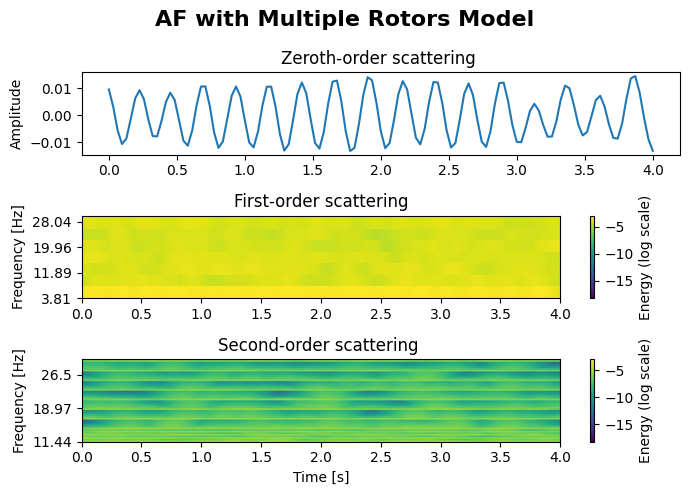

2
2000
[0.000e+00 2.000e-03 4.000e-03 ... 3.994e+00 3.996e+00 3.998e+00]
-21.98013098870236 -2.757001656607441
(125,)
31


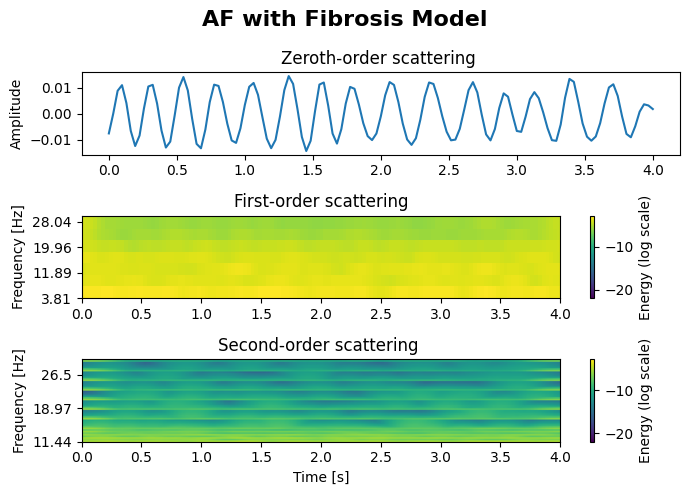

3
2000
[0.000e+00 2.000e-03 4.000e-03 ... 3.994e+00 3.996e+00 3.998e+00]
-18.01308270759169 -3.3273313924879013
(125,)
31


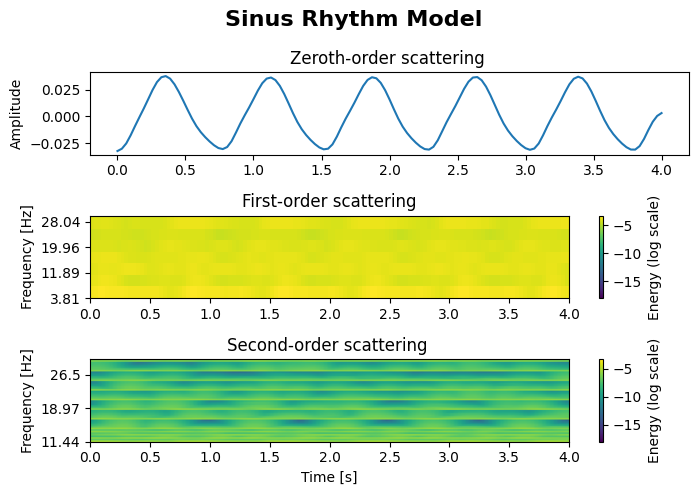

4
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2

In [13]:
# FUNCION QUE APLICA WAVELET SCATTERING PERO ME ENSEÑA LAS FRECUENCIAS EN HZ EN LOS EJES
from kymatio import Scattering1D
def wavelet_scattering(signal, J, Q, fs, type_name=''):
    T = len(signal)
    scattering = Scattering1D(J=J, shape=(T,), Q=Q)


    N = len(X_train_pca[0][0])
    print(N)
    t = np.arange(N) / fs
    print(t)
    
    
    # Obtener coeficientes de scattering y metadatos
    Sx = scattering(signal)
    meta = scattering.meta()

    order_0 = np.where(meta['order'] == 0)[0]
    order_1 = np.where(meta['order'] == 1)[0]
    order_2 = np.where(meta['order'] == 2)[0]

    # Obtener frecuencias a partir de xi
    xi_order1 = meta['xi'][order_1, 0] * (fs / 2)
    xi_order2 = meta['xi'][order_2, 0] * (fs / 2)

    # Filtrar valores NaN
    xi_order1 = xi_order1[~np.isnan(xi_order1)]
    xi_order2 = xi_order2[~np.isnan(xi_order2)]

    # Redondear frecuencias para mejor visualización
    freq_order1 = np.round(xi_order1, 2)
    freq_order2 = np.round(xi_order2, 2)

    log_Sx1 = np.log10(Sx[order_1])
    log_Sx2 = np.log10(Sx[order_2])

    # Rango común para colorbars
    vmin = min(log_Sx1.min(), log_Sx2.min())
    vmax = max(log_Sx1.max(), log_Sx2.max())
    print(vmin, vmax)

    # Seleccionar solo algunas frecuencias para las etiquetas del eje Y
    num_ticks = 15 
    yticks_order1 = np.linspace(freq_order1[0], freq_order1[-1], num_ticks)
    yticks_order2 = np.linspace(freq_order2[0], freq_order2[-1], num_ticks)


     # Ajustar según longitud de coeficientes
    fs_c = fs/(2**J)
    plt.figure(figsize=(7, 5))
    t_coeff = np.linspace(0, N/fs, len(Sx[order_0][0]) )
    print(t_coeff.shape)
    # Zeroth-order scattering
    plt.subplot(3, 1, 1)
    plt.plot(t_coeff, Sx[order_0][0])
    plt.title(f'Zeroth-order scattering ')
    plt.ylabel('Amplitude')
    
    # First-order scattering
    plt.subplot(3, 1, 2)
    plt.imshow(np.log10(Sx[order_1]), aspect='auto', extent=[0, len(Sx[order_1][0])/fs_c, freq_order1[-1], freq_order1[0]], vmin=vmin, vmax=vmax, cmap='viridis')
    plt.title(f'First-order scattering')
    plt.ylabel('Frequency [Hz]')
    plt.yticks(yticks_order1, np.round(yticks_order1, 2))  
    plt.ylim(freq_order1[-1],30) # LIMITO EL EJE A FRECUENCIAS MENORES DE 40 HZ PORQUE ES DONDE ESTÁN LAS FRECUENCIAS DE INTERÉS
    plt.colorbar(label='Energy (log scale)')
    print(len(freq_order1))

    # Second-order scattering
    plt.subplot(3, 1, 3)
    plt.imshow(np.log10(Sx[order_2]), aspect='auto', extent=[0, len(Sx[order_2][0])/fs_c, freq_order2[-1], freq_order2[0]], vmin=vmin, vmax=vmax, cmap='viridis')
    plt.title(f'Second-order scattering ')
    plt.ylabel('Frequency [Hz]')
    plt.yticks(yticks_order2, np.round(yticks_order2, 2))  
    plt.ylim(freq_order2[-1],30)
    plt.colorbar(label='Energy (log scale)')

    plt.xlabel('Time [s]')

    plt.suptitle(f'{type_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

fs = 500  # Ajusta según la frecuencia de tu señal
signal_2 = X_train_pca[30][0]  # Ejemplo de señal
wavelet_scattering(signal_2, J=4, Q=(16,16), fs=500, type_name='AF with Multiple Rotors Model')
print(y_train[30])


fs = 500  # Ajusta según la frecuencia de tu señal
signal_3 = X_train_pca[22][0]  # Ejemplo de señal
wavelet_scattering(signal_3, J=4, Q=(16,16), fs=500, type_name='AF with Fibrosis Model')
print(y_train[22])


fs = 500  # Ajusta según la frecuencia de tu señal
signal_4 = X_train_pca[82][0]  # Ejemplo de señal
wavelet_scattering(signal_4, J=4, Q=(16,16), fs=500, type_name='Sinus Rhythm Model')
print(y_train[82])



print(y_train)

In [54]:
X_train_final = X_train_ws.reshape(X_train_ws.shape[0], -1)
X_test_final = X_test_ws.reshape(X_test_ws.shape[0], -1)

X_train_filt_10dB_final = X_train_filt_10dB_ws.reshape(X_train_filt_10dB_ws.shape[0], -1)
X_test_filt_10dB_final = X_test_filt_10dB_ws.reshape(X_test_filt_10dB_ws.shape[0], -1)

X_train_filt_20dB_final = X_train_filt_20dB_ws.reshape(X_train_filt_20dB_ws.shape[0], -1)
X_test_filt_20dB_final = X_test_filt_20dB_ws.reshape(X_test_filt_20dB_ws.shape[0], -1)

X_train_no_pca_final = X_train_ws_no_pca.reshape(X_train_ws_no_pca.shape[0], -1)
X_test_no_pca_final = X_test_ws_no_pca.reshape(X_test_ws_no_pca.shape[0], -1)

print(f"Datos finales: {X_train_final.shape}, {X_test_final.shape}")
print(f"Datos finales filtrados 10dB: {X_train_filt_10dB_final.shape}, {X_test_filt_10dB_final.shape}")
print(f"Datos finales filtrados 20dB: {X_train_filt_20dB_final.shape}, {X_test_filt_20dB_final.shape}")
print(f"Datos finales sin PCA: {X_train_no_pca_final.shape}, {X_test_no_pca_final.shape}")

Datos finales: (560, 163000), (250, 163000)
Datos finales filtrados 10dB: (560, 163000), (250, 163000)
Datos finales filtrados 20dB: (560, 163000), (250, 163000)
Datos finales sin PCA: (560, 2608000), (250, 2608000)


In [ ]:
# Random Forest Classifier with Hyperparameter Tuning

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, log_loss, f1_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import recall_score, precision_score
def random_forest_100(X_train_final, y_train, X_test_final, y_test):
    # Entrenar el modelo Random Forest
    rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, max_depth=None, bootstrap=True, random_state=42, n_jobs=-1)
    rf.fit(X_train_final, y_train)

    # Predecir clases
    y_pred = rf.predict(X_test_final)

    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    # Obtener probabilidades predichas (necesarias para AUC multiclase y log loss)
    y_proba = rf.predict_proba(X_test_final)  # shape (n_samples, n_classes)

    # AUC ROC multiclase requiere que las etiquetas estén binarizadas (one-hot)
    classes = np.unique(y_test)
    y_test_bin = label_binarize(y_test, classes=classes)

    # Calcular AUC-ROC multiclase (One-vs-Rest)
    auc_roc = roc_auc_score(y_test_bin, y_proba, multi_class='ovr')
    print("AUC-ROC (multiclase OVR):", auc_roc)

    # Calcular Log Loss
    loss = log_loss(y_test_bin, y_proba)
    print("Log loss:", loss)
    return rf

rf_original = random_forest_100(X_train_final, y_train, X_test_final, y_test)
rf_filtered_10dB = random_forest_100(X_train_filt_10dB_final, y_train, X_test_filt_10dB_final, y_test)
rf_filtered_20dB = random_forest_100(X_train_filt_20dB_final, y_train, X_test_filt_20dB_final, y_test)
rf_no_pca = random_forest_100(X_train_no_pca_final, y_train, X_test_no_pca_final, y_test)







from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
# Distribución de búsqueda
def tunning_random_forest(X_train_final, y_train, rf):
    # Crear el modelo Random Forest
    param_dist = {
    'max_depth': [None] + list(range(10, 50, 10)),
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2', None]
}
    random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist,
                                   n_iter=50, cv=5, random_state=42,
                                   n_jobs=-1, verbose=2, scoring='accuracy')

    
    random_search.fit(X_train_final, y_train)
    best_model = random_search.best_estimator_
    print("Mejores hiperparámetros:", random_search.best_params_)
    
#tunning_random_forest(X_train_final, y_train, rf_original)
#tunning_random_forest(X_train_filt_10dB_final, y_train, rf_filtered_10dB)
#tunning_random_forest(X_train_filt_20dB_final, y_train, rf_filtered_20dB)
#tunning_random_forest(X_train_no_pca_final, y_train, rf_no_pca)


Fitting 5 folds for each of 50 candidates, totalling 250 fits


: 

In [55]:
# RANDOM FOREST CLASSIFIER
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, log_loss, f1_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import recall_score, precision_score
def apply_random_forest(X_train_final, y_train, X_test_final, y_test, max_depth, max_features, min_samples_split, min_samples_leaf, bootstrap):
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    import matplotlib.pyplot as plt
    rf = RandomForestClassifier(class_weight='balanced', n_estimators=250, max_depth=max_depth, random_state=42, 
                            max_features=max_features, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, bootstrap=bootstrap, n_jobs=-1)

    rf.fit(X_train_final, y_train)

    # Predecir y evaluar en test
    y_pred = rf.predict(X_test_final)

    cm = confusion_matrix(y_test, y_pred)

    sensitivity = recall_score(y_test, y_pred, average='macro')  # o 'weighted'
    specificity = precision_score(y_test, y_pred, average='macro')  # Approximation

    acc = accuracy_score(y_test, y_pred)
    y_proba = rf.predict_proba(X_test_final)
    
    classes = np.unique(y_test)
    y_test_bin = label_binarize(y_test, classes=classes)
    auc_roc = roc_auc_score(y_test_bin, y_proba, multi_class='ovr')
    log_loss_value = log_loss(y_test, y_proba)
    f1_score_value = f1_score(y_test, rf.predict(X_test_final), average='weighted')

    print(classification_report(y_test, y_pred))
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", cm)
    print("Sensitivity (Recall):", sensitivity)
    print("Specificity:", specificity)
    print("AUC-ROC:", auc_roc)
    print("Log loss:", log_loss_value)

    misclassified_indices = np.where(y_pred != y_test)[0]
    print("\n--- Misclassified examples ---")
    for idx in misclassified_indices:
        print(f"Index: {idx}, Model: {used_test_models[idx]}, True: {y_test[idx]}, Predicted: {y_pred[idx]}")



    #disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    #disp.plot(cmap=plt.cm.Blues)  # Puedes cambiar el color si quieres
    #plt.title("Confusion Matrix")
    #plt.show()


    return acc, cm, sensitivity, specificity, y_proba, auc_roc, log_loss_value, f1_score_value


In [56]:
# Original_data

# Mejores hiperparámetros: {'bootstrap': True, 'max_depth': 40, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 4}

# Mejores hiperparámetros: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 9}
acc, cm, sensitivity, specificity, y_proba, roc_auc, log_loss_, f1_score_ = apply_random_forest(X_train_final, y_train, X_test_final, y_test, max_depth=30, max_features='sqrt', min_samples_split=9, min_samples_leaf=3, bootstrap=True)

              precision    recall  f1-score   support

           2       1.00      0.95      0.97       190
           3       0.67      1.00      0.80        20
           4       1.00      1.00      1.00        40

    accuracy                           0.96       250
   macro avg       0.89      0.98      0.92       250
weighted avg       0.97      0.96      0.96       250

Accuracy: 0.96
Confusion Matrix:
 [[180  10   0]
 [  0  20   0]
 [  0   0  40]]
Sensitivity (Recall): 0.9824561403508771
Specificity: 0.8888888888888888
AUC-ROC: 0.975094075769133
Log loss: 0.14895621240430235

--- Misclassified examples ---
Index: 140, Model: TwoRotors_181219, True: 2, Predicted: 3
Index: 141, Model: TwoRotors_181219, True: 2, Predicted: 3
Index: 142, Model: TwoRotors_181219, True: 2, Predicted: 3
Index: 143, Model: TwoRotors_181219, True: 2, Predicted: 3
Index: 144, Model: TwoRotors_181219, True: 2, Predicted: 3
Index: 145, Model: TwoRotors_181219, True: 2, Predicted: 3
Index: 146, Model: TwoR

In [57]:
# filtered_data_10dB

# Mejores hiperparámetros: {'bootstrap': True, 'max_depth': 40, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 6}
# Mejores hiperparámetros: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 8}
acc_filt_10dB, cm_filt_10dB, sensitivity_filt_10dB, specificity_filt_10dB, y_proba_filt_10dB, roc_auc_filt_10dB, log_loss_filt_10dB, f1_score_filt_10dB = apply_random_forest(X_train_filt_10dB_final, y_train, X_test_filt_10dB_final, y_test, max_depth=20, max_features='sqrt', min_samples_split=8, min_samples_leaf=2, bootstrap=True)


              precision    recall  f1-score   support

           2       1.00      0.99      0.99       190
           3       0.91      1.00      0.95        20
           4       1.00      1.00      1.00        40

    accuracy                           0.99       250
   macro avg       0.97      1.00      0.98       250
weighted avg       0.99      0.99      0.99       250

Accuracy: 0.992
Confusion Matrix:
 [[188   2   0]
 [  0  20   0]
 [  0   0  40]]
Sensitivity (Recall): 0.9964912280701754
Specificity: 0.9696969696969697
AUC-ROC: 1.0
Log loss: 0.09193024446383696

--- Misclassified examples ---
Index: 141, Model: TwoRotors_181219, True: 2, Predicted: 3
Index: 146, Model: TwoRotors_181219, True: 2, Predicted: 3


In [58]:
# filtered_data_20dB

# Mejores hiperparámetros: {'bootstrap': False, 'max_depth': 40, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 2}
#Mejores hiperparámetros: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 9}
acc_filt_20dB, cm_filt_20dB, sensitivity_filt_20dB, specificity_filt_20dB, y_proba_filt_20dB, roc_auc_filt_20dB, log_loss_filt_20dB, f1_score_filt_20dB = apply_random_forest(X_train_filt_20dB_final, y_train, X_test_filt_20dB_final, y_test, max_depth=30, max_features='sqrt', min_samples_split=9, min_samples_leaf=3, bootstrap=True)


              precision    recall  f1-score   support

           2       1.00      0.97      0.98       190
           3       0.77      1.00      0.87        20
           4       1.00      1.00      1.00        40

    accuracy                           0.98       250
   macro avg       0.92      0.99      0.95       250
weighted avg       0.98      0.98      0.98       250

Accuracy: 0.976
Confusion Matrix:
 [[184   6   0]
 [  0  20   0]
 [  0   0  40]]
Sensitivity (Recall): 0.9894736842105263
Specificity: 0.923076923076923
AUC-ROC: 0.9999122807017544
Log loss: 0.07865819391188617

--- Misclassified examples ---
Index: 141, Model: TwoRotors_181219, True: 2, Predicted: 3
Index: 142, Model: TwoRotors_181219, True: 2, Predicted: 3
Index: 143, Model: TwoRotors_181219, True: 2, Predicted: 3
Index: 144, Model: TwoRotors_181219, True: 2, Predicted: 3
Index: 146, Model: TwoRotors_181219, True: 2, Predicted: 3
Index: 147, Model: TwoRotors_181219, True: 2, Predicted: 3


In [59]:
# no PCA

# Mejores hiperparámetros: {'bootstrap': False, 'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 3}
acc_no_pca, cm_no_pca, sensitivity_no_pca, specificity_no_pca, y_proba_no_pca, roc_auc_no_pca, log_loss_no_pca, f1_score_no_pca = apply_random_forest(X_train_no_pca_final, y_train, X_test_no_pca_final, y_test, max_depth=20, max_features='sqrt', min_samples_split=9, min_samples_leaf=3, bootstrap=True)

              precision    recall  f1-score   support

           2       1.00      0.95      0.97       190
           3       0.67      1.00      0.80        20
           4       1.00      1.00      1.00        40

    accuracy                           0.96       250
   macro avg       0.89      0.98      0.92       250
weighted avg       0.97      0.96      0.96       250

Accuracy: 0.96
Confusion Matrix:
 [[180  10   0]
 [  0  20   0]
 [  0   0  40]]
Sensitivity (Recall): 0.9824561403508771
Specificity: 0.8888888888888888
AUC-ROC: 0.9810500889905924
Log loss: 0.13316998827397372

--- Misclassified examples ---
Index: 140, Model: TwoRotors_181219, True: 2, Predicted: 3
Index: 141, Model: TwoRotors_181219, True: 2, Predicted: 3
Index: 142, Model: TwoRotors_181219, True: 2, Predicted: 3
Index: 143, Model: TwoRotors_181219, True: 2, Predicted: 3
Index: 144, Model: TwoRotors_181219, True: 2, Predicted: 3
Index: 145, Model: TwoRotors_181219, True: 2, Predicted: 3
Index: 146, Model: Two

###
### **CHARACTERIZATION OF PROBLEMATIC MODEL**

55
55
['LA_RSPV_CAF_150115', 'Simulation_01_200316_001_  5', 'Simulation_01_191001_001_002', 'Simulation_01_200428_001_005', 'Simulation_01_190717_001_001', 'Simulation_01_200212_001_  7', 'Simulation_01_191001_001_007', 'LA_RSPV_150113', 'Simulation_01_190717_001_004', 'Simulation_01_200212_001_  1', 'LA_LSPV_150203', 'Simulation_01_190619_001_003', 'Simulation_01_200428_001_003', 'Simulation_01_190619_001_004', 'Simulation_01_190717_001_003', 'Simulation_01_190502_001_006', 'LA_LSPV_150113', 'Simulation_01_190502_001_004', 'RA_RAFW_140807', 'Simulation_01_190717_001_002', 'Simulation_01_200316_001_  3', 'Simulation_01_200316_001_  4', 'RA_RAA_141230', 'Sinusal_150629', 'RA_RAA_141216', 'Simulation_01_200428_001_002', 'Simulation_01_190619_001_001', 'Simulation_01_200212_001_  9', 'Simulation_01_200316_001_  1', 'Simulation_01_200316_001_  8', 'Simulation_01_200428_001_004', 'Simulation_01_200212_001_  8', 'Simulation_01_200212_001_ 10', 'Simulation_01_191001_001_001', 'Simulation_01_

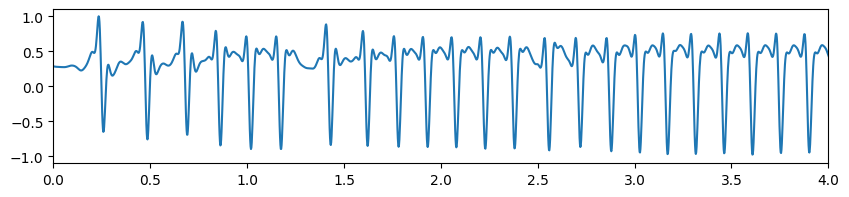

Simulation_01_190502_001_006
2
Índice: 15
Shape del EGM: (2048, 4000)


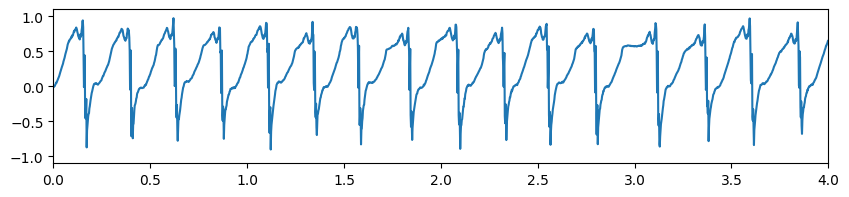

LA_LSPV_150113
3
Índice: 16
Shape del EGM: (2048, 2499)


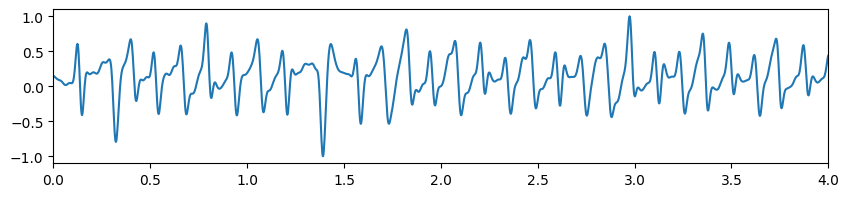

Índice: 42
Shape del EGM: (2048, 2000)


In [11]:
print(len(egms_filtered_norm))
print(len(filtered_models_egm))
target_name = "TwoRotors_181219"

print(filtered_models_egm)

# Modelo dos rotores que claisifca mal (como AFFibr)
model_name = "TwoRotors_181219"
idx = np.where(np.array(filtered_models_egm) == model_name)[0][0]
egm_vector = egms_filtered_norm[idx]

print("Índice:", idx)
print("Shape del EGM:", egm_vector.shape)

print(used_test_models[140]) 
print(y_test[140])

egms_filtered_norm[38]
t = np.arange(len(egms_filtered_norm[38][0])) / 500  
plt.figure(figsize=(10, 2))
plt.plot(t, egms_filtered_norm[38][0])
plt.xlim(0,4)
plt.show()

# Modelo dos rotores que clasifica bien (Simulation_01_190502_001_006)
print(used_test_models[245]) 
print(y_test[245])

model_name = "Simulation_01_190502_001_006"
idx = np.where(np.array(filtered_models_egm) == model_name)[0][0]
egm_vector = egms_filtered_norm[idx]

print("Índice:", idx)
print("Shape del EGM:", egm_vector.shape)

t = np.arange(len(egms_filtered_norm[15][100])) / 500  
plt.figure(figsize=(10, 2))
plt.plot(t, egms_filtered_norm[15][0])
plt.xlim(0,4)
plt.show()

# Modelo con fibrosis que clasifica bien (LA_LSPV_150113)
print(used_test_models[135]) 
print(y_test[135])

model_name = "LA_LSPV_150113"
idx = np.where(np.array(filtered_models_egm) == model_name)[0][0]
egm_vector = egms_filtered_norm[idx]
print("Índice:", idx)
print("Shape del EGM:", egm_vector.shape)

t = np.arange(len(egms_filtered_norm[16][10])) / 500  
plt.figure(figsize=(10, 2))
plt.plot(t, egms_filtered_norm[16][2000])
plt.xlim(0, 4)
plt.show()






model_name = "LA_PLAW_140711_arm"
idx = np.where(np.array(filtered_models_egm) == model_name)[0][0]
egm_vector = egms_filtered_norm[idx]

print("Índice:", idx)
print("Shape del EGM:", egm_vector.shape)

250
Modelo dos rotores (2) que claisifca mal (como AFFibr (3))
Índices encontrados: [140 141 142 143 144 145 146 147 148 149]
Modelo dos rotores (2) que clasifica bien 
Índices encontrados: [230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247
 248 249]
Modelo con fibrosis (3) que clasifica bien 
Índices encontrados: [130 131 132 133 134 135 136 137 138 139]


Text(0.5, 1.0, 'Modelo con fibrosis (3) que clasifica bien')

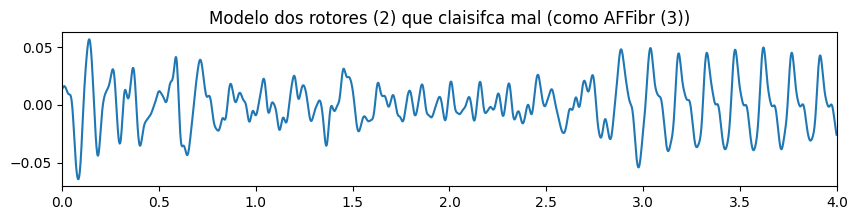

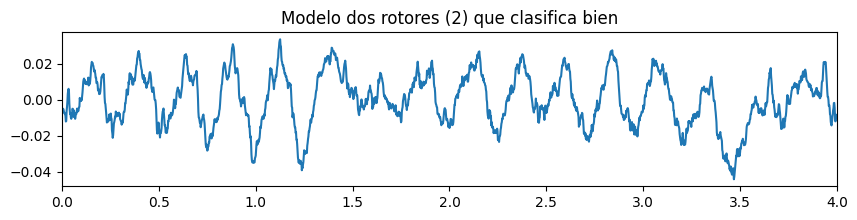

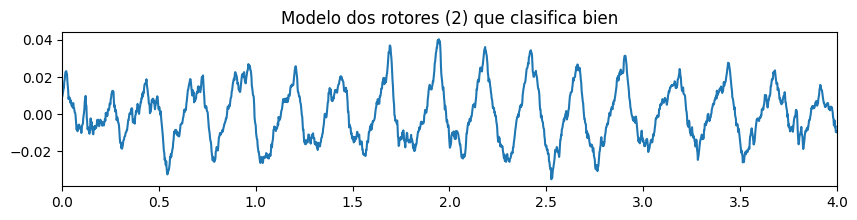

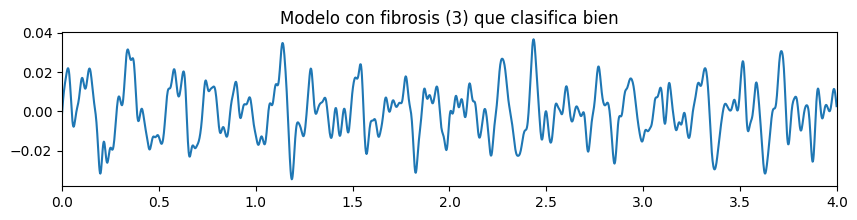

In [12]:
#indices = np.where(used_test_models == "TwoRotors_181219")[0][0]
#print("Índices encontrados:", indices)
#X_test_pca[38]
print(len(used_test_models))

# Modelo dos rotores que claisifca mal (como AFFibr)
print("Modelo dos rotores (2) que claisifca mal (como AFFibr (3))")
indices = np.where(np.array(used_test_models) == "TwoRotors_181219")[0]
print("Índices encontrados:", indices)

t = np.arange(len(X_test_pca[141][0])) / 500
plt.figure(figsize=(10, 2))
plt.plot(t, X_test_pca[141][0])
plt.xlim(0, 4)
plt.title("Modelo dos rotores (2) que claisifca mal (como AFFibr (3))")

# Modelo dos rotores que clasifica bien (Simulation_01_190502_001_006)
print("Modelo dos rotores (2) que clasifica bien ")
indices = np.where(np.array(used_test_models) == "Simulation_01_190502_001_006")[0]
print("Índices encontrados:", indices)

t = np.arange(len(X_test_pca[231][0])) / 500
plt.figure(figsize=(10, 2))
plt.plot(t, X_test_pca[231][0])
plt.xlim(0, 4)
plt.title("Modelo dos rotores (2) que clasifica bien")
t = np.arange(len(X_test_pca[244][0])) / 500
plt.figure(figsize=(10, 2))
plt.plot(t, X_test_pca[244][0])
plt.xlim(0, 4)
plt.title("Modelo dos rotores (2) que clasifica bien")


# Modelo con fibrosis que clasifica bien (LA_LSPV_150113)
print("Modelo con fibrosis (3) que clasifica bien ")
indices = np.where(np.array(used_test_models) == "LA_LSPV_150113")[0]
print("Índices encontrados:", indices)

t = np.arange(len(X_test_pca[133][0])) / 500
plt.figure(figsize=(10, 2))
plt.plot(t, X_test_pca[133][0])
plt.xlim(0, 4)
plt.title("Modelo con fibrosis (3) que clasifica bien")


250
Modelo dos rotores (2) que claisifca mal (como AFFibr (3))
Índices encontrados: [140 141 142 143 144 145 146 147 148 149]
Modelo dos rotores (2) que clasifica bien 
Índices encontrados: [230 231 232 233 234 235 236 237 238 239 240 241 242 243 244 245 246 247
 248 249]
Modelo con fibrosis (3) que clasifica bien 
Índices encontrados: [130 131 132 133 134 135 136 137 138 139]


Text(0.5, 1.0, 'Modelo con fibrosis (3) que clasifica bien')

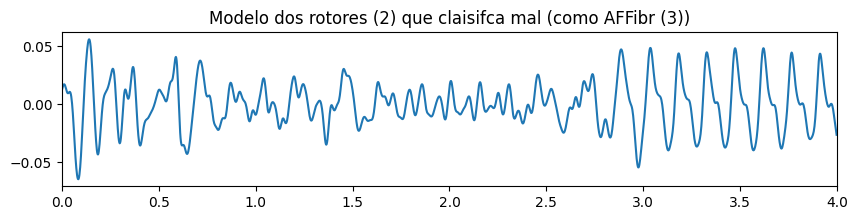

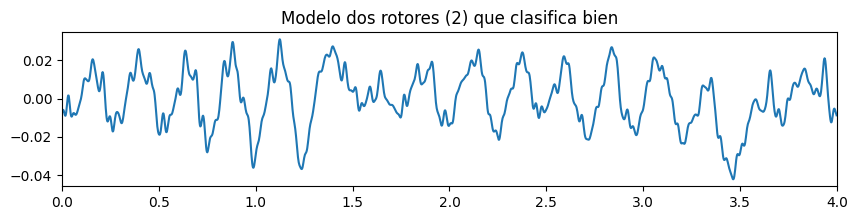

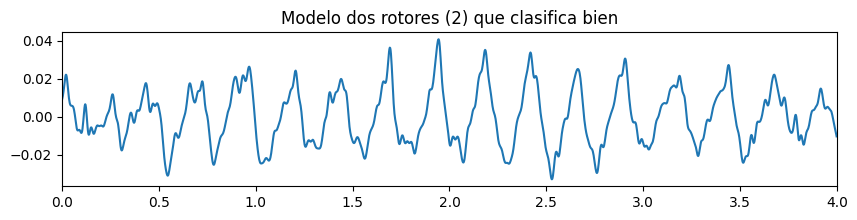

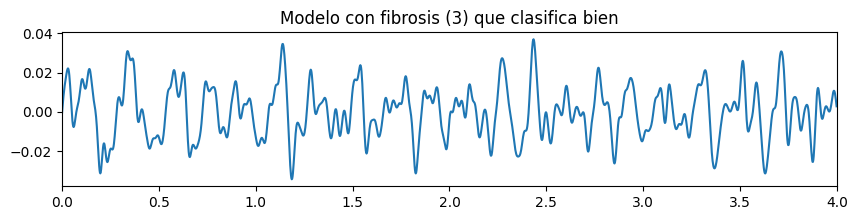

In [13]:
#indices = np.where(used_test_models == "TwoRotors_181219")[0][0]
#print("Índices encontrados:", indices)
#X_test_pca[38]
print(len(used_test_models))

# Modelo dos rotores que claisifca mal (como AFFibr)
print("Modelo dos rotores (2) que claisifca mal (como AFFibr (3))")
indices = np.where(np.array(used_test_models) == "TwoRotors_181219")[0]
print("Índices encontrados:", indices)

t = np.arange(len(X_test_filt_10dB_pca[141][0])) / 500
plt.figure(figsize=(10, 2))
plt.plot(t, X_test_filt_10dB_pca[141][0])
plt.xlim(0, 4)
plt.title("Modelo dos rotores (2) que claisifca mal (como AFFibr (3))")

# Modelo dos rotores que clasifica bien (Simulation_01_190502_001_006)
print("Modelo dos rotores (2) que clasifica bien ")
indices = np.where(np.array(used_test_models) == "Simulation_01_190502_001_006")[0]
print("Índices encontrados:", indices)

t = np.arange(len(X_test_filt_10dB_pca[231][0])) / 500
plt.figure(figsize=(10, 2))
plt.plot(t, X_test_filt_10dB_pca[231][0])
plt.xlim(0, 4)
plt.title("Modelo dos rotores (2) que clasifica bien")
t = np.arange(len(X_test_filt_10dB_pca[244][0])) / 500
plt.figure(figsize=(10, 2))
plt.plot(t, X_test_filt_10dB_pca[244][0])
plt.xlim(0, 4)
plt.title("Modelo dos rotores (2) que clasifica bien")


# Modelo con fibrosis que clasifica bien (LA_LSPV_150113)
print("Modelo con fibrosis (3) que clasifica bien ")
indices = np.where(np.array(used_test_models) == "LA_LSPV_150113")[0]
print("Índices encontrados:", indices)

t = np.arange(len(X_test_filt_10dB_pca[133][0])) / 500
plt.figure(figsize=(10, 2))
plt.plot(t, X_test_filt_10dB_pca[133][0])
plt.xlim(0, 4)
plt.title("Modelo con fibrosis (3) que clasifica bien")


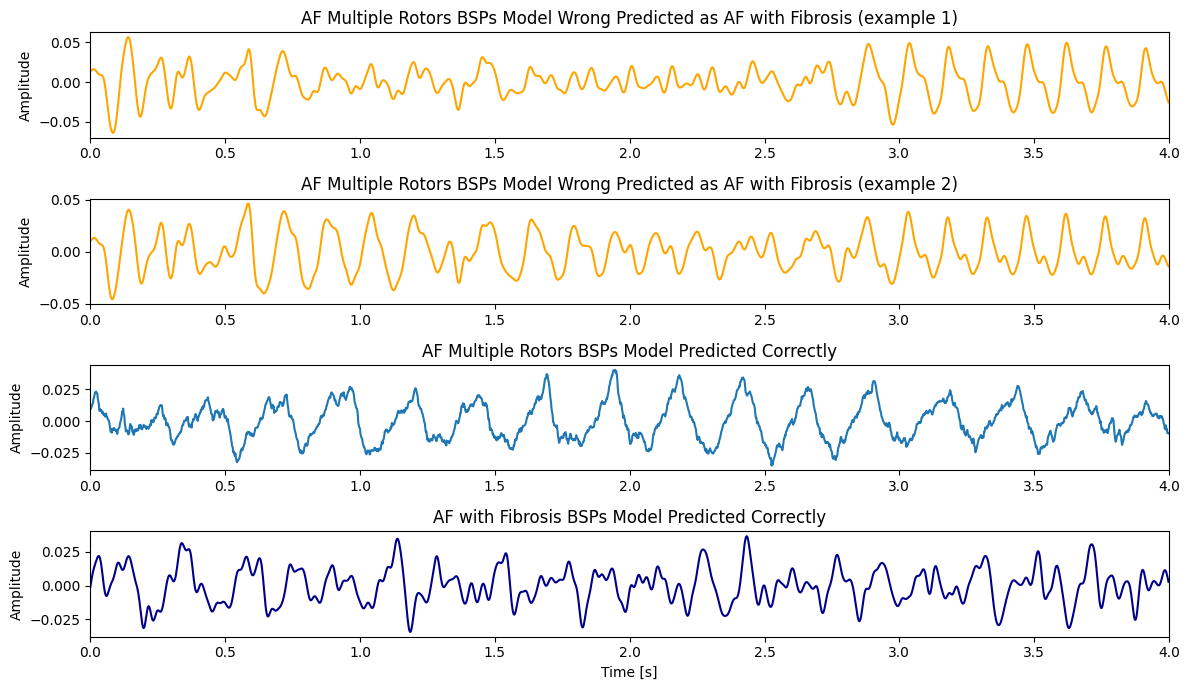

In [14]:
import matplotlib.pyplot as plt
import numpy as np

fig, axs = plt.subplots(4, 1, figsize=(12, 7))  # 4 filas, 1 columna

# === Gráfico 1: dos rotores que clasifica mal ===
idx_mal = 141
t1 = np.arange(len(X_test_pca[idx_mal][0])) / 500
axs[0].plot(t1, X_test_pca[idx_mal][0], color='orange')
axs[0].set_xlim(0, 4)
axs[0].set_title("AF Multiple Rotors BSPs Model Wrong Predicted as AF with Fibrosis (example 1)")
axs[0].set_ylabel("Amplitude")

idx_mal = 146
t1 = np.arange(len(X_test_pca[idx_mal][0])) / 500
axs[1].plot(t1, X_test_pca[idx_mal][0], color='orange')
axs[1].set_xlim(0, 4)
axs[1].set_title("AF Multiple Rotors BSPs Model Wrong Predicted as AF with Fibrosis (example 2)")
axs[1].set_ylabel("Amplitude")

# === Gráfico 3: dos rotores que clasifica bien (segundo ejemplo) ===
idx_bien2 = 244
t3 = np.arange(len(X_test_pca[idx_bien2][0])) / 500
axs[2].plot(t3, X_test_pca[idx_bien2][0])
axs[2].set_xlim(0, 4)
axs[2].set_title("AF Multiple Rotors BSPs Model Predicted Correctly")
axs[2].set_ylabel("Amplitude")
# === Gráfico 4: modelo con fibrosis que clasifica bien ===
idx_fibrosis = 133
t4 = np.arange(len(X_test_pca[idx_fibrosis][0])) / 500
axs[3].plot(t4, X_test_pca[idx_fibrosis][0], color='darkblue')
axs[3].set_xlim(0, 4)
axs[3].set_title("AF with Fibrosis BSPs Model Predicted Correctly")
axs[3].set_xlabel("Time [s]")
axs[3].set_ylabel("Amplitude")


# Ajustar layout para evitar solapamiento
plt.tight_layout()
plt.show()


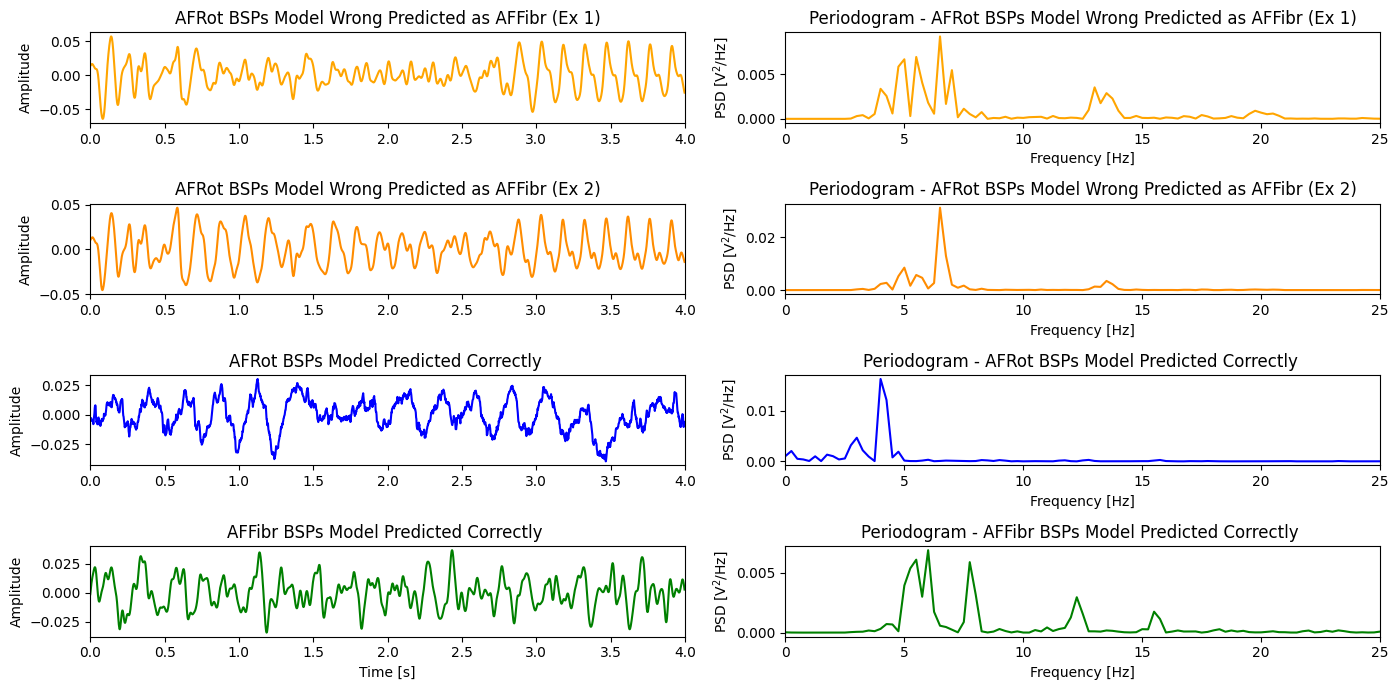

In [33]:
import matplotlib.pyplot as plt
import numpy as np

def compute_psd(signal, fs):
    N = len(signal)
    # fft con ventana Hanning para suavizar (opcional)
    window = np.hanning(N)
    fft_signal = np.fft.fft(signal * window)
    freqs = np.fft.fftfreq(N, d=1/fs)
    Pxx = (np.abs(fft_signal)**2) / N
    pos_freqs = freqs[:N//2]
    positive_Pxx = Pxx[:N//2]
    return pos_freqs, positive_Pxx

fig, axs = plt.subplots(4, 2, figsize=(14, 7))  # 4 filas, 2 columnas

fs = 500  # frecuencia de muestreo

# Señales para graficar
indices = [141, 146, 237, 133]
titles = [
    "AFRot BSPs Model Wrong Predicted as AFFibr (Ex 1)",
    "AFRot BSPs Model Wrong Predicted as AFFibr (Ex 2)",
    "AFRot BSPs Model Predicted Correctly ", 
    "AFFibr BSPs Model Predicted Correctly "
]

colors = ['orange', 'darkorange', 'blue', 'green']

for i, idx in enumerate(indices):
    signal = X_test_pca[idx][0]
    t = np.arange(len(signal)) / fs
    
    # Plot señal en la primera columna
    axs[i, 0].plot(t, signal, color=colors[i])
    axs[i, 0].set_xlim(0, 4)
    axs[i, 0].set_title(titles[i])
    axs[i, 0].set_ylabel("Amplitude")
    if i == 3:
        axs[i, 0].set_xlabel("Time [s]")
    
    # Calcular PSD y plotear en la segunda columna
    freqs, psd = compute_psd(signal, fs)
    axs[i, 1].plot(freqs, psd, color=colors[i])
    axs[i, 1].set_xlim(0, 25)  # limite en frecuencia (ejemplo)
    axs[i, 1].set_title(f"Periodogram - {titles[i]}")
    axs[i, 1].set_xlabel("Frequency [Hz]")
    axs[i, 1].set_ylabel("PSD [V$^2$/Hz]")

plt.tight_layout()
plt.show()


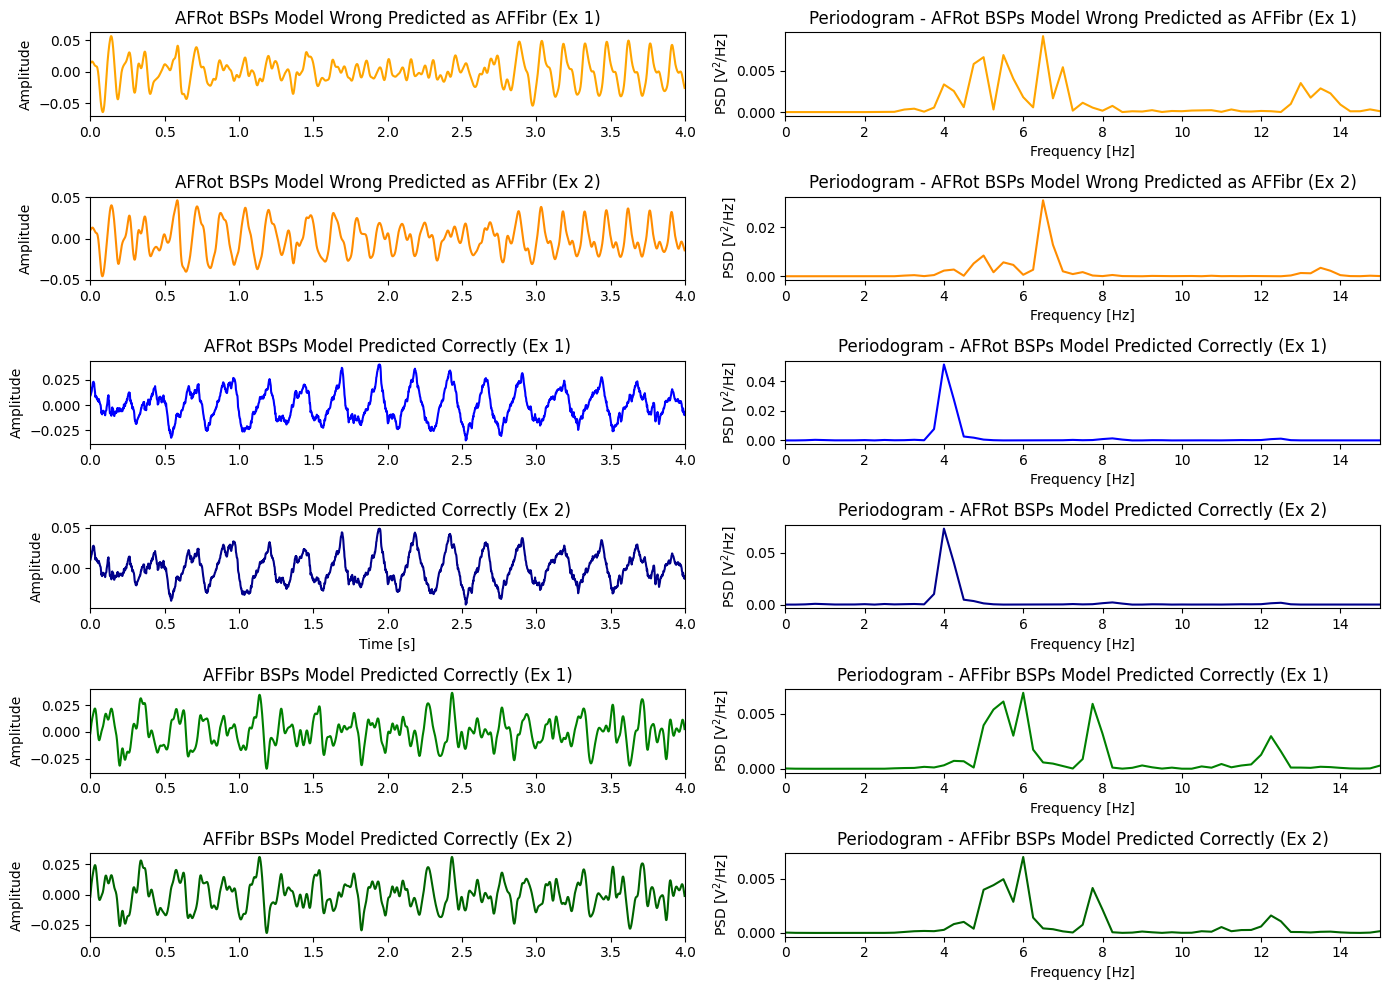

In [24]:
import matplotlib.pyplot as plt
import numpy as np

def compute_psd(signal, fs):
    N = len(signal)
    # fft con ventana Hanning para suavizar (opcional)
    window = np.hanning(N)
    fft_signal = np.fft.fft(signal * window)
    freqs = np.fft.fftfreq(N, d=1/fs)
    Pxx = (np.abs(fft_signal)**2) / N
    pos_freqs = freqs[:N//2]
    positive_Pxx = Pxx[:N//2]
    return pos_freqs, positive_Pxx

fig, axs = plt.subplots(6, 2, figsize=(14, 10))  # 4 filas, 2 columnas

fs = 500  # frecuencia de muestreo

# Señales para graficar
indices = [141, 146, 244, 230, 133, 139]
titles = [
    "AFRot BSPs Model Wrong Predicted as AFFibr (Ex 1)",
    "AFRot BSPs Model Wrong Predicted as AFFibr (Ex 2)",
    "AFRot BSPs Model Predicted Correctly (Ex 1)", 
    "AFRot BSPs Model Predicted Correctly (Ex 2)",
    "AFFibr BSPs Model Predicted Correctly (Ex 1)", 
    "AFFibr BSPs Model Predicted Correctly (Ex 2)"
]

colors = ['orange', 'darkorange', 'blue', 'darkblue', 'green', 'darkgreen']

for i, idx in enumerate(indices):
    signal = X_test_pca[idx][0]
    t = np.arange(len(signal)) / fs
    
    # Plot señal en la primera columna
    axs[i, 0].plot(t, signal, color=colors[i])
    axs[i, 0].set_xlim(0, 4)
    axs[i, 0].set_title(titles[i])
    axs[i, 0].set_ylabel("Amplitude")
    if i == 3:
        axs[i, 0].set_xlabel("Time [s]")
    
    # Calcular PSD y plotear en la segunda columna
    freqs, psd = compute_psd(signal, fs)
    axs[i, 1].plot(freqs, psd, color=colors[i])
    axs[i, 1].set_xlim(0, 15)  # limite en frecuencia (ejemplo)
    axs[i, 1].set_title(f"Periodogram - {titles[i]}")
    axs[i, 1].set_xlabel("Frequency [Hz]")
    axs[i, 1].set_ylabel("PSD [V$^2$/Hz]")

plt.tight_layout()
plt.show()


regiones (2039,)
uint8
[5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5
 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 5 4 5 5 5 5 5 5 4 5 5 5 5 4
 5 5 5 5 5 4 5 5 5 4 5 4 4 4 5 4 4 4 5 4 4 5 4 5 4 4]
[1 2 3 4 5 6 7]
REGION 1:  [1246 1262 1283 1287 1294 1298 1320 1334 1341 1353 1354 1356 1377 1381
 1386 1394 1396 1400 1403 1404 1407 1410 1417 1418 1419 1420 1424 1426
 1427 1434 1439 1440 1441 1443 1445 1447 1448 1450 1453 1456 1457 1467
 1471 1472 1473 1479 1481 1487 1492 1503 1505 1512 1516 1522 1523 1535
 1538 1539 1541 1551 1554 1561 1563 1566 1568 1570 1574 1576 1580 1583
 1588 1592 1595 1598 1601 1603 1605 1613 1617 1618 1622 1626 1628 1629
 1631 1632 1634 1636 1643 1645 1646 1649 1651 1652 1653 1657 1661 1662
 1663 1664 1667 1668 1671 1676 1680 1687 1688 1689 1693 1694 1699 1700
 1701 1702 1705 1706 1709 1711 1712 1714 1715 1717 1719 1720 1722 1727
 1731 1732 1737 1738 1741 1742 1743 1744 1746 1748 1749 1751 1753 1754
 1760 1761 1763 1769 1772 1775 1776 

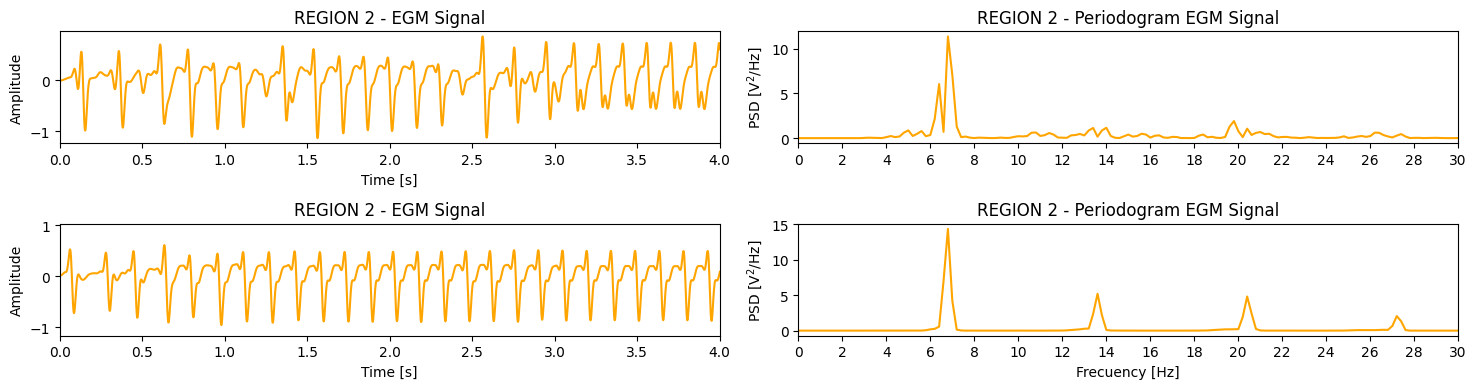

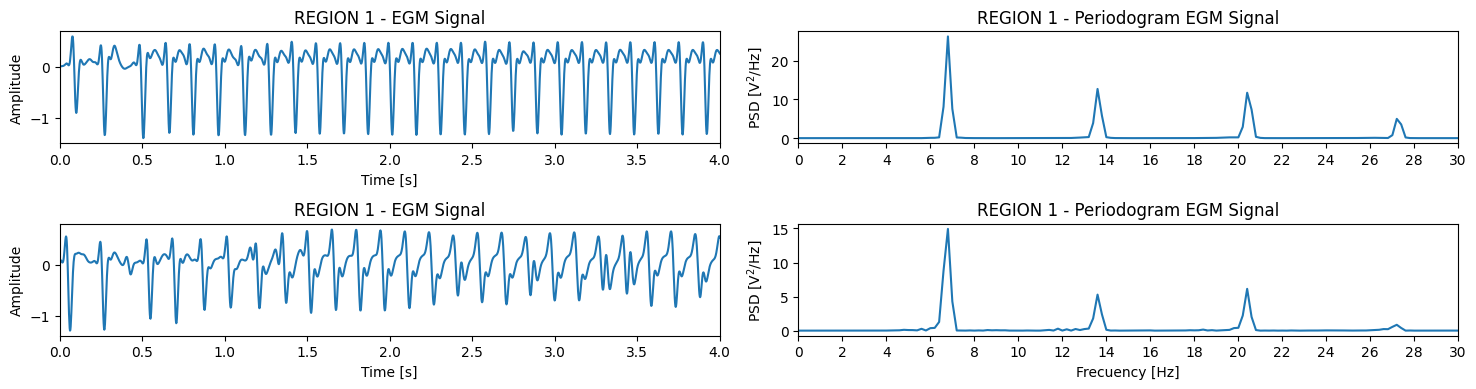

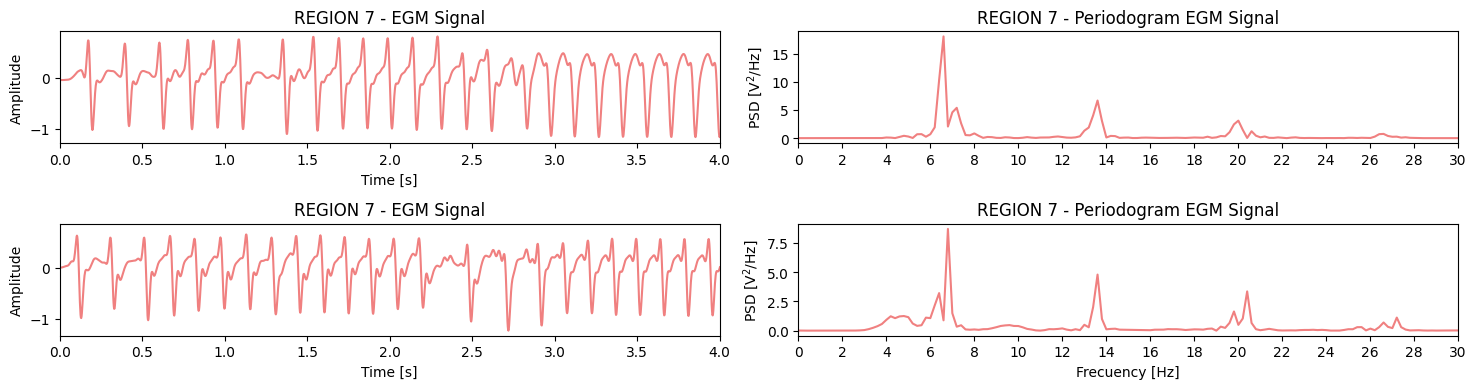

In [53]:
import numpy as np
import os
from scipy.io import loadmat

def get_multilabel(model_name, n_regiones=7):
    path_driver_position = f"../../Data/{model_name}/driver_position_2.mat"

    if not os.path.exists(path_driver_position):
        return np.zeros(n_regiones, dtype=int)  # Sinusal

    driver_position = loadmat(path_driver_position)["driver_position"]
    nodes_aux = driver_position[:, 1]
    driver_position = driver_position[:, 0]
    

    regions = loadmat("../../Data/regions.mat")["regions"][0]

    labels = []
    for idx in range(len(driver_position)):
        if driver_position[idx] != 0:
            node_idx = int(nodes_aux[idx][0, 0]) - 1  # índice en regiones
            if 0 <= node_idx < len(regions):
                region_label = int(regions[node_idx])
                labels.append(region_label)

    # Convertimos a binario multi-etiqueta
    multilabel = np.zeros(n_regiones, dtype=int)
    for r in labels:
        if 1 <= r <= n_regiones:
            multilabel[r - 1] = 1

    regions = np.array(regions)  # si no es array aún
    print("regiones", regions.shape)
    print(regions.dtype)
    print(regions[0:100])
    print(np.unique(regions))
    nodos_region_1 = np.where(regions == 1)[0]
    nodos_region_2 = np.where(regions == 2)[0]
    nodos_region_3 = np.where(regions == 3)[0]
    nodos_region_4 = np.where(regions == 4)[0]
    nodos_region_5 = np.where(regions == 5)[0]
    nodos_region_6 = np.where(regions == 6)[0]
    nodos_region_7 = np.where(regions == 7)[0]
    print("REGION 1: ", nodos_region_1)
    print("REGION 2: ", nodos_region_2)
    print("REGION 3: ",nodos_region_3)
    print("REGION 4: ", nodos_region_4)
    print("REGION 5: ", nodos_region_5)
    print("REGION 6: ", nodos_region_6)
    print("REGION 7: ", nodos_region_7)

    return multilabel, nodos_region_2, nodos_region_1, nodos_region_7


name = "TwoRotors_181219"  # Ejemplo de nombre de modelo
labels_multilabel, nodos_region_2, nodos_region_1, nodos_region_7 = get_multilabel(name)
print(labels_multilabel)

signal_mal_2rot = egms_filtered_norm[38]
print(signal_mal_2rot.shape)  # debería salir (2048, 2499)

print(len(signal_mal_2rot[0]))
# REGION 2
signals_2reg = []
for i in nodos_region_2:
    signals_2reg.append(signal_mal_2rot[i])
signals_2reg = np.array(signals_2reg)
print("REGION 2", len(signals_2reg))

# REGION 1
signals_1reg = []
for i in nodos_region_1:
    signals_1reg.append(signal_mal_2rot[i])
signals_1reg = np.array(signals_1reg)
print("REGION 1", len(signals_1reg))

# REGION 7
signals_7reg = []
for i in nodos_region_7:
    signals_7reg.append(signal_mal_2rot[i])
signals_7reg = np.array(signals_7reg)
print("REGION 7", len(signals_7reg))



indices_2reg = [23, 198]
fig, axs = plt.subplots(2, 2, figsize=(15, 4))  # 3 filas, 2 columnas

for row, idx in enumerate(indices_2reg):
    signal = signals_2reg[idx]  # Accedemos correctamente a la señal
    signal = signal - np.mean(signal)  # Centrado
    t = np.arange(len(signal)) / 500  # Tiempo

    axs[row, 0].plot(t, signal, color='orange')
    axs[row, 0].set_xlim(0, 4)
    axs[row, 0].set_title(f"REGION 2 - EGM Signal")
    axs[row, 0].set_xlabel("Time [s]")
    axs[row, 0].set_ylabel("Amplitude")

    freqs, psd = compute_psd(signal, fs=500)
    axs[row, 1].plot(freqs, psd, color='orange')
    axs[row, 1].set_xlim(0, 30)
    axs[row, 1].set_xticks(np.arange(0, 31, 2))
    axs[row, 1].set_title(f"REGION 2 - Periodogram EGM Signal")
    if row == 1:
        axs[row, 1].set_xlabel("Frecuency [Hz]")
    axs[row, 1].set_ylabel("PSD [V$^2$/Hz]")

plt.tight_layout()
plt.show()




indices_3reg = [20, 190]
fig, axs = plt.subplots(2, 2, figsize=(15, 4))  # 3 filas, 2 columnas

for row, i in enumerate(indices_3reg):
    signal_1reg = signals_1reg[i]
    signal_1reg = signal_1reg - np.mean(signal_1reg) 
    t = np.arange(len(signal_1reg)) / 500  

    # Señal temporal
    axs[row, 0].plot(t, signal_1reg)
    axs[row, 0].set_xlim(0, 4)
    axs[row, 0].set_title(f"REGION 1 - EGM Signal")
    axs[row, 0].set_xlabel("Time [s]")
    axs[row, 0].set_ylabel("Amplitude")

    # PSD
    freqs, psd = compute_psd(signal_1reg, fs=500)
    axs[row, 1].plot(freqs, psd)
    axs[row, 1].set_xlim(0, 30)
    axs[row, 1].set_xticks(np.arange(0, 31, 2))
    axs[row, 1].set_title(f"REGION 1 - Periodogram EGM Signal")
    #axs[row, 1].set_xlabel("Frecuency [Hz]")
    axs[row, 1].set_ylabel("PSD [V$^2$/Hz]")
    if row == 1:
        axs[row, 1].set_xlabel("Frecuency [Hz]")

plt.tight_layout()
plt.show()



indices_7reg = [30, 140]
fig, axs = plt.subplots(2, 2, figsize=(15, 4))  # 3 filas, 2 columnas

for row, i in enumerate(indices_7reg):
    signal_7reg = signals_7reg[i]
    signal_7reg = signal_7reg - np.mean(signal_7reg) 
    t = np.arange(len(signal_7reg)) / 500  

    # Señal temporal
    axs[row, 0].plot(t, signal_7reg, color='lightcoral')
    axs[row, 0].set_xlim(0, 4)
    axs[row, 0].set_title(f"REGION 7 - EGM Signal")
    axs[row, 0].set_xlabel("Time [s]")
    axs[row, 0].set_ylabel("Amplitude")

    # PSD
    freqs, psd = compute_psd(signal_7reg, fs=500)
    axs[row, 1].plot(freqs, psd, color='lightcoral')
    axs[row, 1].set_xlim(0, 30)
    axs[row, 1].set_xticks(np.arange(0, 31, 2))
    axs[row, 1].set_title(f"REGION 7 - Periodogram EGM Signal")
    #axs[row, 1].set_xlabel("Frecuency [Hz]")
    axs[row, 1].set_ylabel("PSD [V$^2$/Hz]")
    if row == 1:
        axs[row, 1].set_xlabel("Frecuency [Hz]")

plt.tight_layout()
plt.show()




#### PARA MODELO QUE SI QUE CLASIFICA BIEN COMO MULTIPLE ROTORS

[array([[0]], dtype=uint8) array([[0]], dtype=uint8)
 array([[0]], dtype=uint8) ... array([[1]], dtype=uint8)
 array([[0]], dtype=uint8) array([[0]], dtype=uint8)]
Valor [[0]]: 18 veces
Valor [[1]]: 1982 veces
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

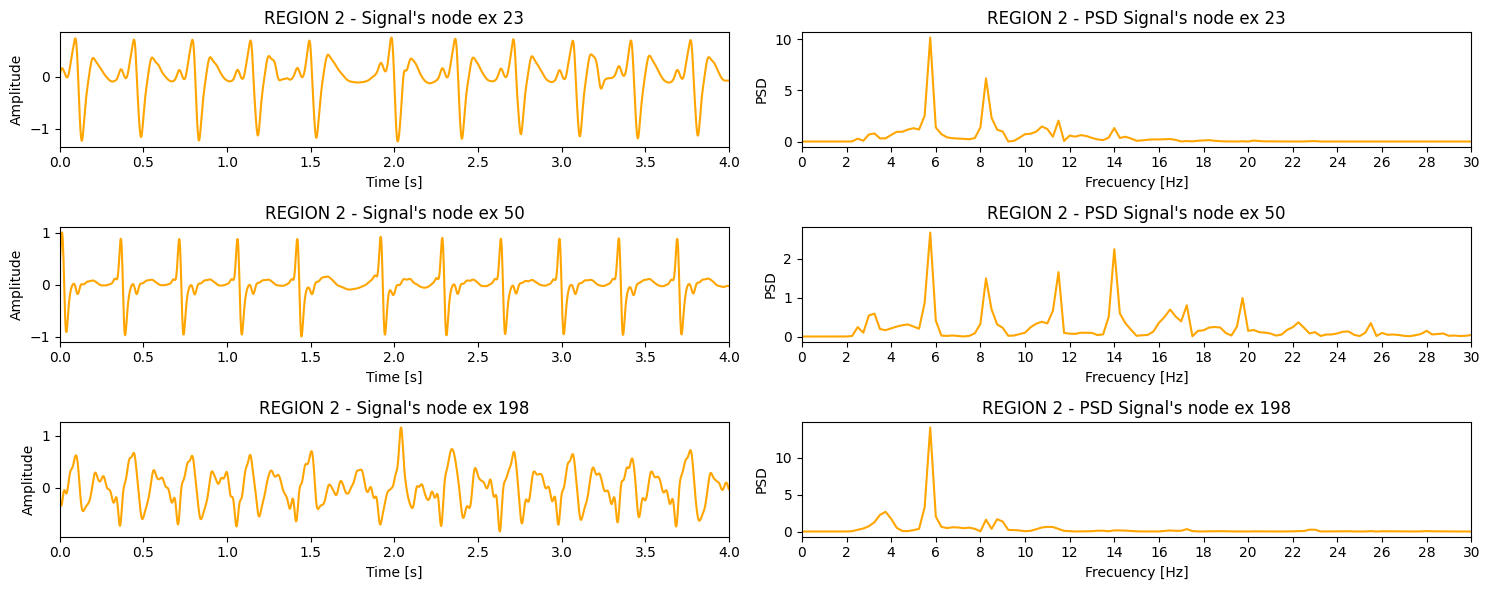

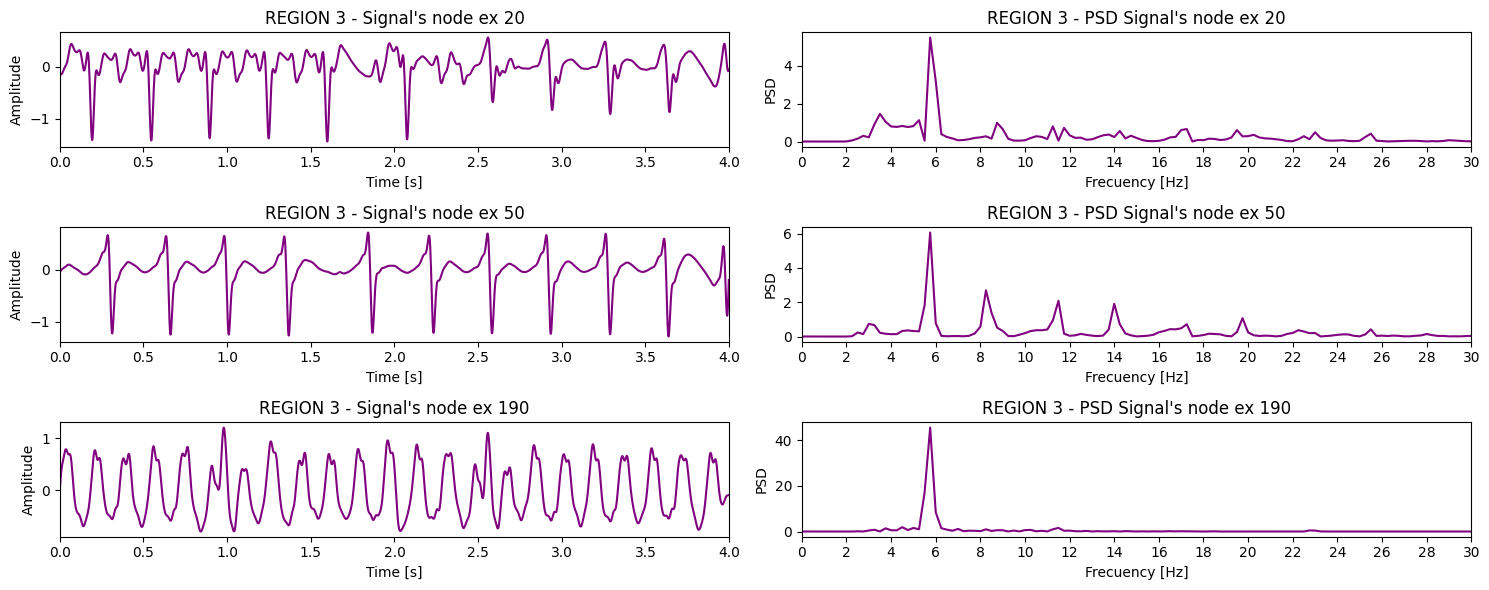

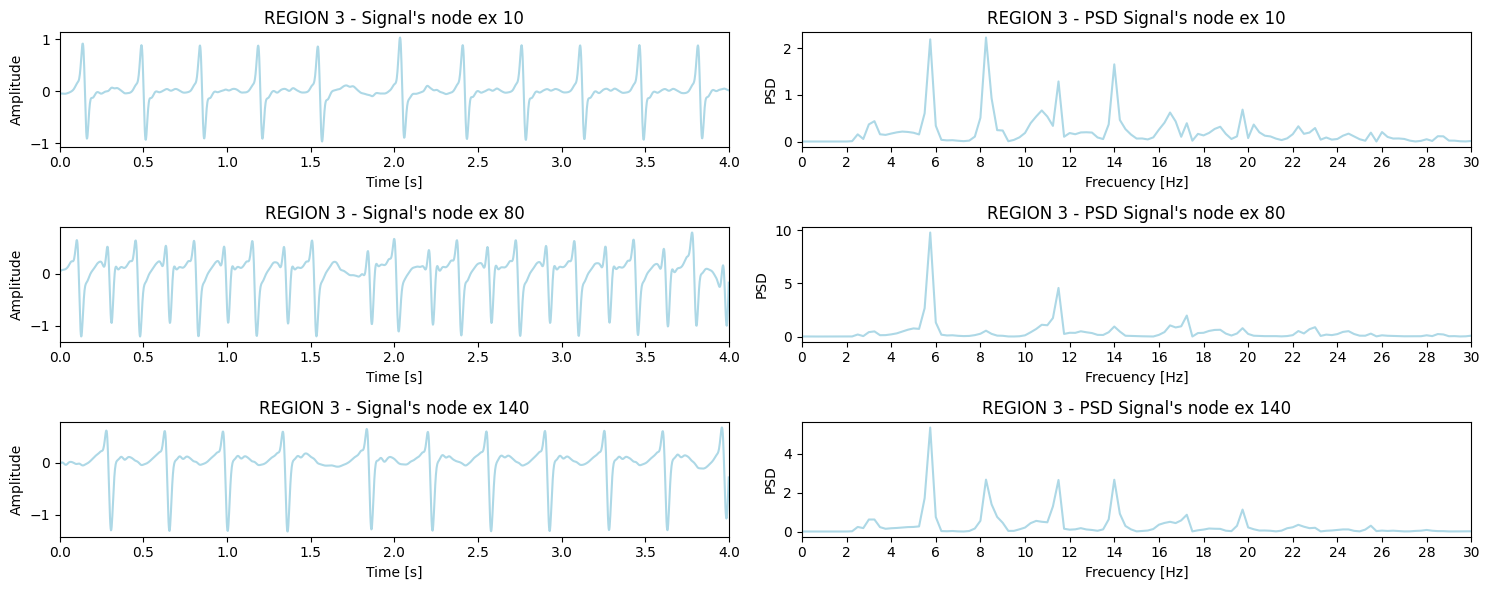

In [84]:
import numpy as np
import os
from scipy.io import loadmat

def get_multilabel(model_name, n_regiones=6):
    path_driver_position = f"../../Data/{model_name}/driver_position.mat"

    if not os.path.exists(path_driver_position):
        return np.zeros(n_regiones, dtype=int)  # Sinusal

    driver_position = loadmat(path_driver_position)["driver_position"]
    nodes_aux = driver_position[:, 1]
    driver_position = driver_position[:, 0]
    print(driver_position)
    valores, cuentas = np.unique(driver_position, return_counts=True)

    # Mostrar resultados
    for valor, cuenta in zip(valores, cuentas):
        print(f"Valor {valor}: {cuenta} veces")

    regions = loadmat("../../Data/regions.mat")["regions"][0]

    labels = []
    for idx in range(len(driver_position)):
        if driver_position[idx] != 0:
            node_idx = int(nodes_aux[idx][0, 0]) - 1  # índice en regiones
            if 0 <= node_idx < len(regions):
                region_label = int(regions[node_idx])
                labels.append(region_label)
    print(labels)
    # Convertimos a binario multi-etiqueta
    multilabel = np.zeros(n_regiones, dtype=int)
    for r in labels:
        if 1 <= r <= n_regiones:
            multilabel[r - 1] = 1

    regions = np.array(regions)  # si no es array aún
    nodos_region_1 = np.where(regions == 1)[0]
    nodos_region_2 = np.where(regions == 2)[0]
    nodos_region_3 = np.where(regions == 3)[0]
    nodos_region_4 = np.where(regions == 4)[0]
    nodos_region_5 = np.where(regions == 5)[0]
    nodos_region_6 = np.where(regions == 6)[0]
    nodos_region_7 = np.where(regions == 7)[0]

    return multilabel, nodos_region_2, nodos_region_3, nodos_region_7


name_2 = "LA_PLAW_140711_arm"  # Ejemplo de nombre de modelo
labels_multilabel_, nodos_region_2, nodos_region_3, nodos_region_7 = get_multilabel(name_2)
print(labels_multilabel_)

signal_bien_2rot = egms_filtered_norm[42]
print(signal_bien_2rot.shape)  # debería salir (2048, 2499)

print(len(signal_bien_2rot[0]))
# REGION 2
signals_2reg = []
for i in nodos_region_2:
    signals_2reg.append(signal_bien_2rot[i])
signals_2reg = np.array(signals_2reg)
print("REGION 2", len(signals_2reg))

# REGION 3
signals_3reg = []
for i in nodos_region_3:
    signals_3reg.append(signal_bien_2rot[i])
signals_3reg = np.array(signals_3reg)
print("REGION 3", len(signals_3reg))

# REGION 6
signals_7reg = []
for i in nodos_region_7:
    signals_7reg.append(signal_bien_2rot[i])
signals_7reg = np.array(signals_7reg)
print("REGION 7", len(signals_7reg))



indices_2reg = [23, 50, 198]
fig, axs = plt.subplots(3, 2, figsize=(15, 6))  # 3 filas, 2 columnas

for row, idx in enumerate(indices_2reg):
    signal = signals_2reg[idx]  # Accedemos correctamente a la señal
    signal = signal - np.mean(signal)  # Centrado
    t = np.arange(len(signal)) / 500  # Tiempo

    axs[row, 0].plot(t, signal, color='orange')
    axs[row, 0].set_xlim(0, 4)
    axs[row, 0].set_title(f"REGION 2 - Signal's node ex {idx}")
    axs[row, 0].set_xlabel("Time [s]")
    axs[row, 0].set_ylabel("Amplitude")

    freqs, psd = compute_psd(signal, fs=500)
    axs[row, 1].plot(freqs, psd, color='orange')
    axs[row, 1].set_xlim(0, 30)
    axs[row, 1].set_xticks(np.arange(0, 31, 2))
    axs[row, 1].set_title(f"REGION 2 - PSD Signal's node ex {idx}")
    axs[row, 1].set_xlabel("Frecuency [Hz]")
    axs[row, 1].set_ylabel("PSD")

plt.tight_layout()
plt.show()




indices_3reg = [20, 50, 190]
fig, axs = plt.subplots(3, 2, figsize=(15, 6))  # 3 filas, 2 columnas

for row, i in enumerate(indices_3reg):
    signal_3reg = signals_3reg[i]
    signal_3reg = signal_3reg - np.mean(signal_3reg) 
    t = np.arange(len(signal_3reg)) / 500  

    # Señal temporal
    axs[row, 0].plot(t, signal_3reg, color='purple')
    axs[row, 0].set_xlim(0, 4)
    axs[row, 0].set_title(f"REGION 3 - Signal's node ex {i}")
    axs[row, 0].set_xlabel("Time [s]")
    axs[row, 0].set_ylabel("Amplitude")

    # PSD
    freqs, psd = compute_psd(signal_3reg, fs=500)
    axs[row, 1].plot(freqs, psd, color='purple')
    axs[row, 1].set_xlim(0, 30)
    axs[row, 1].set_xticks(np.arange(0, 31, 2))
    axs[row, 1].set_title(f"REGION 3 - PSD Signal's node ex {i}")
    axs[row, 1].set_xlabel("Frecuency [Hz]")
    axs[row, 1].set_ylabel("PSD")

plt.tight_layout()
plt.show()



indices_7reg = [10, 80, 140]
fig, axs = plt.subplots(3, 2, figsize=(15, 6))  # 3 filas, 2 columnas

for row, i in enumerate(indices_7reg):
    signal_7reg = signals_7reg[i]
    signal_7reg = signal_7reg - np.mean(signal_7reg) 
    t = np.arange(len(signal_7reg)) / 500  

    # Señal temporal
    axs[row, 0].plot(t, signal_7reg, color='lightblue')
    axs[row, 0].set_xlim(0, 4)
    axs[row, 0].set_title(f"REGION 3 - Signal's node ex {i}")
    axs[row, 0].set_xlabel("Time [s]")
    axs[row, 0].set_ylabel("Amplitude")

    # PSD
    freqs, psd = compute_psd(signal_7reg, fs=500)
    axs[row, 1].plot(freqs, psd, color='lightblue')
    axs[row, 1].set_xlim(0, 30)
    axs[row, 1].set_xticks(np.arange(0, 31, 2))
    axs[row, 1].set_title(f"REGION 3 - PSD Signal's node ex {i}")
    axs[row, 1].set_xlabel("Frecuency [Hz]")
    axs[row, 1].set_ylabel("PSD")

plt.tight_layout()
plt.show()




###
### **MULTICLASS CLASSIFICATION RESULTS**

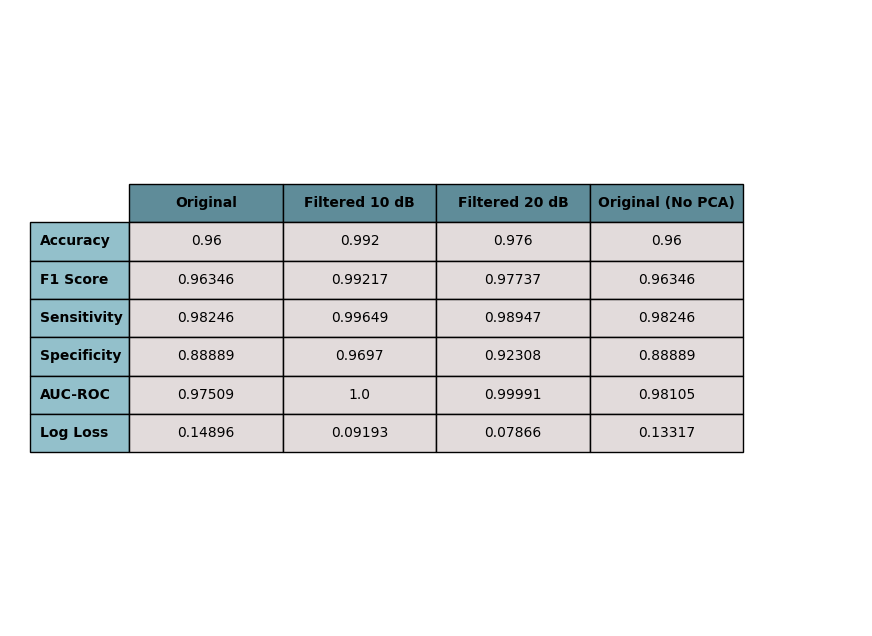

In [60]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import table

# Datos de ejemplo (rellena con tus variables reales)
metrics_dict = {
    'Original': {
        'Accuracy': acc,
        'F1 Score': f1_score_,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'AUC-ROC': roc_auc,
        'Log Loss': log_loss_,
    },
    'Filtered 10 dB': {
        'Accuracy': acc_filt_10dB,
        'F1 Score': f1_score_filt_10dB,
        'Sensitivity': sensitivity_filt_10dB,
        'Specificity': specificity_filt_10dB,
        'AUC-ROC': roc_auc_filt_10dB,
        'Log Loss': log_loss_filt_10dB,
    },
    'Filtered 20 dB': {
        'Accuracy': acc_filt_20dB,
        'F1 Score': f1_score_filt_20dB,
        'Sensitivity': sensitivity_filt_20dB,
        'Specificity': specificity_filt_20dB,
        'AUC-ROC': roc_auc_filt_20dB,
        'Log Loss': log_loss_filt_20dB,
    },
    'Original (No PCA)': {
        'Accuracy': acc_no_pca,
        'F1 Score': f1_score_no_pca,
        'Sensitivity': sensitivity_no_pca,
        'Specificity': specificity_no_pca,
        'AUC-ROC': roc_auc_no_pca,
        'Log Loss': log_loss_no_pca,
    },
}

import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import table

# Crear el DataFrame y redondear
df_metrics = pd.DataFrame(metrics_dict).round(5)

# Crear figura y tabla
fig, ax = plt.subplots(figsize=(11, 8))
ax.axis('off')
tbl = table(ax, df_metrics, loc='center', cellLoc='center', colWidths=[0.15]*df_metrics.shape[1])

# Estética general
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 2.3)

# Aplicar estilo a encabezados
for (row, col), cell in tbl.get_celld().items():
    if row == 0:  # encabezados
        cell.set_text_props(weight='bold', color='black')
        cell.set_facecolor("#5f8c99")  # gris claro
    elif col == -1:  # fila de índices (las métricas)
        cell.set_text_props(weight='bold')
        cell.set_facecolor("#93c0cb")

    else:
        cell.set_facecolor("#dbd2d2cc")

# Guardar imagen
plt.savefig("styled_metrics_table.png", bbox_inches='tight', dpi=300)
plt.show()


In [62]:
unique_classes = np.unique(y_test)
print(unique_classes)
label_map = {
    2: 'AF Rotors',
    3: 'AF Fib',
    4: 'N'
}
class_names = [label_map[i] for i in unique_classes]
print(class_names)

[2 3 4]
['AF Rotors', 'AF Fib', 'N']


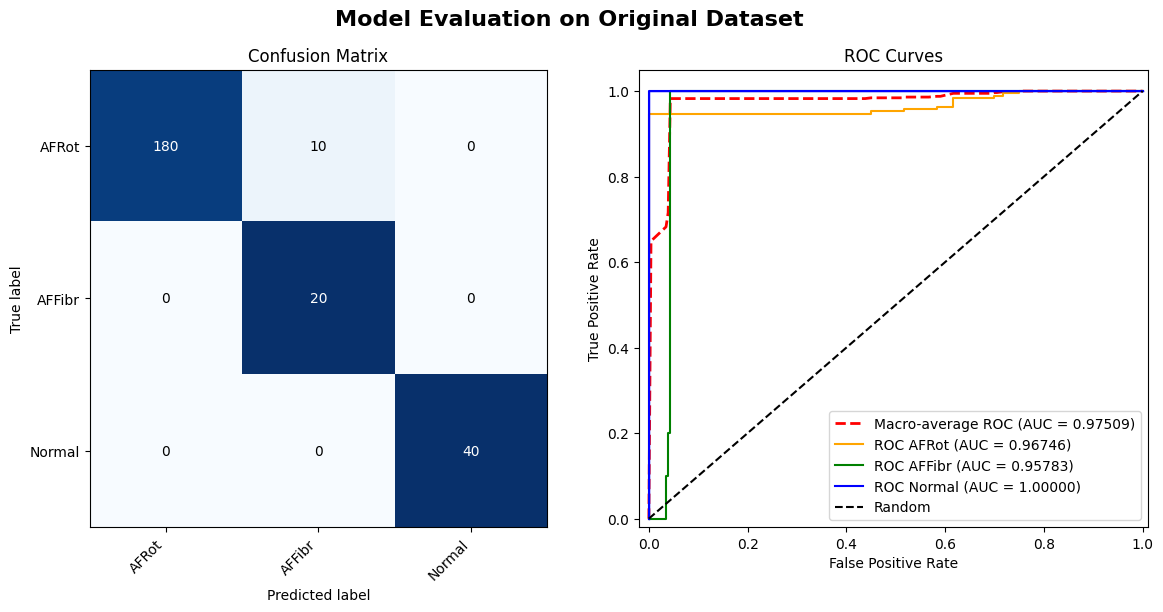

Individual AUCs: {0: 0.9674561403508771, 1: 0.9578260869565217, 2: 1.0}
Macro-average AUC: 0.975094075769133
mean_tpr: [0.         0.64912281 0.68245614 0.71578947 0.98245614 0.98245614
 0.98245614 0.98245614 0.98245614 0.98245614 0.98245614 0.98245614
 0.98245614 0.98245614 0.98245614 0.98245614 0.98245614 0.98245614
 0.98245614 0.98245614 0.98245614 0.98245614 0.98245614 0.98245614
 0.98245614 0.98245614 0.98245614 0.98245614 0.98245614 0.98245614
 0.98421053 0.98421053 0.98421053 0.98421053 0.98421053 0.98421053
 0.98421053 0.98596491 0.98596491 0.98596491 0.98596491 0.9877193
 0.9877193  0.99473684 0.99473684 0.99473684 0.99473684 0.99473684
 0.99473684 0.99473684 0.99649123 0.99649123 0.99824561 0.99824561
 0.99824561 0.99824561 1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.        ]


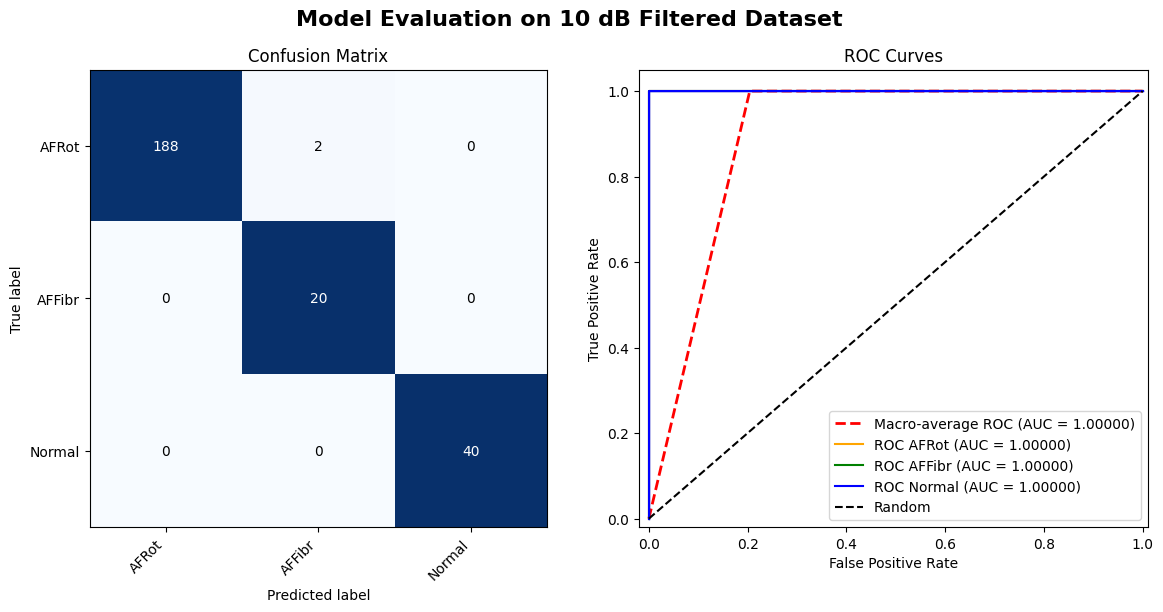

Individual AUCs: {0: 1.0, 1: 1.0, 2: 1.0}
Macro-average AUC: 1.0
mean_tpr: [0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1.]


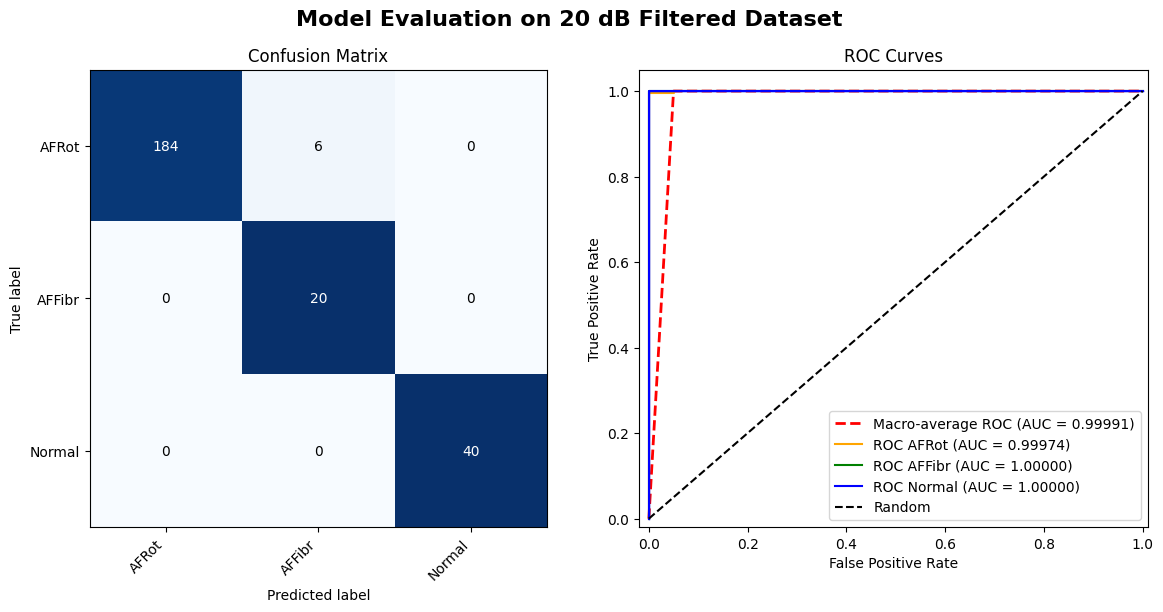

Individual AUCs: {0: 0.9997368421052631, 1: 1.0, 2: 1.0}
Macro-average AUC: 0.9999122807017544
mean_tpr: [0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


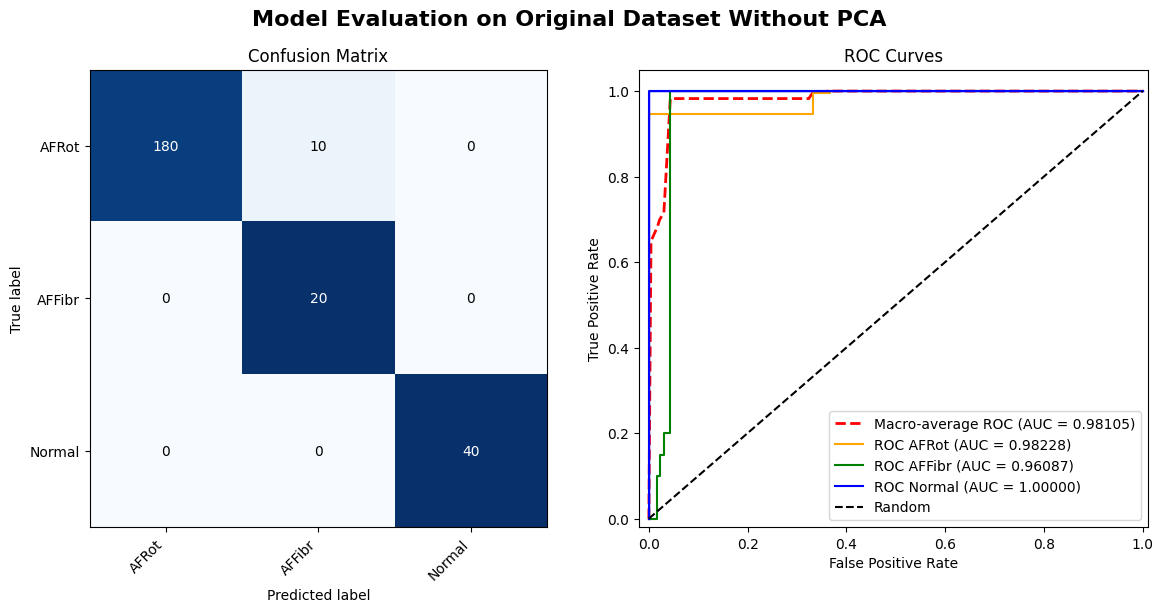

Individual AUCs: {0: 0.982280701754386, 1: 0.9608695652173913, 2: 1.0}
Macro-average AUC: 0.9810500889905924
mean_tpr: [0.         0.64912281 0.68245614 0.69912281 0.71578947 0.98245614
 0.98245614 0.98245614 0.98245614 0.98245614 0.98245614 0.98245614
 0.98245614 0.98245614 0.98245614 0.98245614 0.98245614 0.98245614
 0.98245614 0.98245614 0.98245614 0.98245614 0.98245614 0.98245614
 0.98245614 0.98245614 0.98245614 0.98245614 0.98245614 0.98245614
 0.99824561 0.99824561 1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.         1.         1.
 1.         1.         1.         1.        ]


In [68]:
def plot_confusion_and_global_roc_all_curves(cm, y_test, y_proba, class_names, title_plot):
    from matplotlib import rcParams
    rcParams['axes.edgecolor'] = 'black'
    from sklearn.preprocessing import label_binarize
    from sklearn.metrics import roc_curve, auc
    import numpy as np
    import matplotlib.pyplot as plt

    # Binarizar etiquetas para ROC multiclase
    y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
    n_classes = y_test_bin.shape[1]

    # ROC Curve por clase
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr_i, tpr_i, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        # Forzar incluir (0,0) y (1,1)
        fpr[i] = np.insert(fpr_i, 0, 0.0)
        tpr[i] = np.insert(tpr_i, 0, 0.0)
        if fpr[i][-1] != 1.0:
            fpr[i] = np.append(fpr[i], 1.0)
            tpr[i] = np.append(tpr[i], 1.0)
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Macro-average (direct mean of AUCs for consistency)
    auc_macro = np.mean(list(roc_auc.values()))

    # Interpolated mean_tpr for visualization (optional, can be removed if AUC mean is preferred)
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    if all_fpr[0] == 0.0:
        mean_tpr[0] = 0.0

    # ----- Visualización -----
    fig, axs = plt.subplots(1, 2, figsize=(12, 6))
    plt.suptitle(title_plot, fontsize=16, fontweight='bold')

    # Matriz de Confusión coloreada proporcional por fila
    cm_color = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    im = axs[0].imshow(cm_color, interpolation='nearest', cmap=plt.cm.Blues)
    axs[0].set_title("Confusion Matrix", color='black')
    axs[0].set_xticks(np.arange(len(class_names)))
    axs[0].set_yticks(np.arange(len(class_names)))
    axs[0].set_xticklabels(class_names, rotation=45, ha="right", color='black')
    axs[0].set_yticklabels(class_names, color='black')
    axs[0].set_xlabel('Predicted label', color='black')
    axs[0].set_ylabel('True label', color='black')

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm_color[i, j] > 0.5 else "black"
            axs[0].text(j, i, str(cm[i, j]), ha="center", va="center", color=color)

    axs[0].tick_params(axis='both', colors='black')
    axs[0].grid(False)

    # Curva ROC Global + por clase
    axs[1].plot(all_fpr, mean_tpr, 'r--', label=f'Macro-average ROC (AUC = {auc_macro:.5f})', linewidth=2)

    colors = ['orange', 'green', 'blue', 'red']
    for i, color in zip(range(n_classes), colors):
        axs[1].plot(fpr[i], tpr[i], color=color,
                    label=f'ROC {class_names[i]} (AUC = {roc_auc[i]:.5f})')
        if color == 'blue':
            axs[1].plot(fpr[i], tpr[i], color=color, linewidth=1)

    axs[1].plot([0, 1], [0, 1], 'k--', label='Random')
    axs[1].set_xlim([-0.02, 1.01])
    axs[1].set_ylim([-0.02, 1.05])
    axs[1].set_xlabel('False Positive Rate', color='black')
    axs[1].set_ylabel('True Positive Rate', color='black')
    axs[1].set_title('ROC Curves', color='black')
    axs[1].tick_params(axis='both', colors='black')
    axs[1].legend(loc="lower right")

    plt.tight_layout()
    plt.show()

    print("Individual AUCs:", roc_auc)
    print("Macro-average AUC:", auc_macro)
    print("mean_tpr:", mean_tpr)


plot_confusion_and_global_roc_all_curves(cm, y_test, y_proba, class_names, title_plot="Model Evaluation on Original Dataset")
plot_confusion_and_global_roc_all_curves(cm_filt_10dB, y_test, y_proba_filt_10dB, class_names, title_plot="Model Evaluation on 10 dB Filtered Dataset")
plot_confusion_and_global_roc_all_curves(cm_filt_20dB, y_test, y_proba_filt_20dB, class_names,  title_plot="Model Evaluation on 20 dB Filtered Dataset")
plot_confusion_and_global_roc_all_curves(cm_no_pca, y_test, y_proba_no_pca, class_names,  title_plot="Model Evaluation on Original Dataset Without PCA")

